In [3]:
import cartopy.crs as ccrs
import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from tools import time_from_attr,open_L2_CLOUD_GPC,plot_hist
from matplotlib.colors import LogNorm
from scipy.stats import chi2
from collision_coalescence import CC_growth_rates_retrieval
import shapely.geometry as sgeom
import cartopy.feature as cfeature
from shapely.prepared import prep
import numpy as np
import time
from pathlib import Path
from scipy.spatial import cKDTree  # only needed for fallback remap


In [4]:
auth = earthaccess.login(persist=True)

In [5]:
def open_L2_CLOUD_GPC(path,bounding_box=(-170,-60,-120,-50)):
    """
    Args:
        path: a path to a dataset corresponding to one Level-2 granule
        bounding_box: optional argument of bounding box for region (defaults to Southern Ocean)
    Returns:
        the dataset restricted to the bounding_box region, with specific variables, and with the datetime added as time coord
    """
    dt = xr.open_datatree(path)
    ds = xr.merge(dt.to_dict().values())
    ds = time_from_attr(ds)
    ds = ds.set_coords(('latitude','longitude'))
    ds = ds[['cloud_bow_droplet_effective_radius',
             'cloud_bow_droplet_effective_variance',
             'cloud_bow_droplet_number_concentration_adiabatic',
             'cloud_bow_liquid_water_path','cloud_optical_thickness',
             'cloud_top_altitude','cloud_top_temperature','cloud_top_pressure',
             'cloud_liquid_index',
             'cloud_rft_droplet_effective_radius_mode_0','cloud_rft_droplet_effective_variance_mode_0',
             'cloud_bow_rms','cloud_bow_fit_correlation']]
    #anc_name = ds.aux_file
    #s3_uri   = f"s3://ob-cumulus-prod-public/{anc_name}"
    #ds_anc = xr.open_dataset(s3_uri, engine="h5netcdf",chunks="auto")
    
    W,S,E,N = bounding_box
    lat_mask = np.logical_and(ds.latitude<=N,ds.latitude>=S)
    lon_mask = np.logical_and(ds.longitude<=E,ds.longitude>=W)
    #land_mask = vec_is_over_land(ds.longitude,ds.latitude)
    mask = np.logical_and(lat_mask,lon_mask)#,land_mask)
    ds = ds.where(mask,drop=True)
    return(ds)

## Establish land surface mask
# Load land polygons at coarse resolution
land_geom = cfeature.NaturalEarthFeature('physical', 'land', '110m')
land_polygons = list(land_geom.geometries())
land = prep(sgeom.MultiPolygon(land_polygons))

def is_over_land(lat, lon):
    point = sgeom.Point(lon, lat)
    return land.contains(point)

# Vectorize for arrays
vec_is_over_land = np.vectorize(is_over_land)

In [6]:
import os, json, hashlib
import numpy as np
from pathlib import Path
import cartopy.feature as cfeature
import shapely
import shapely.geometry as sgeom
import shapely.ops as sops

CACHE_DIR = Path("landmask_cache")
CACHE_DIR.mkdir(exist_ok=True)

def _cache_path(bbox, res_deg, ne_res):
    key = json.dumps({"bbox": bbox, "res": float(res_deg), "ne": ne_res})
    h = hashlib.sha1(key.encode()).hexdigest()[:12]
    return CACHE_DIR / f"landmask_{h}_{res_deg}deg_{ne_res}.npz"

def _grid_for_box(w, s, e, n, res_deg):
    lat_vec = np.arange(s, n + res_deg, res_deg, dtype=np.float32)
    lon_vec = np.arange(w, e + res_deg, res_deg, dtype=np.float32)
    lon2d, lat2d = np.meshgrid(lon_vec, lat_vec)
    return lat_vec, lon_vec, lat2d, lon2d

def build_bbox_landmask(bbox, res_deg=0.1, ne_res="50m", use_cache=True):
    """
    Precompute a land mask over the bbox at 'res_deg' resolution.
    Returns: lat_vec [Ny], lon_vec [Nx], land_bool [Ny,Nx] (True=land)
    """
    W, S, E, N = bbox
    cache = _cache_path(bbox, res_deg, ne_res)
    if use_cache and cache.exists():
        z = np.load(cache)
        return z["lat_vec"], z["lon_vec"], z["land_bool"]

    # Load Natural Earth land polygons and union into one geometry
    land_feat = cfeature.NaturalEarthFeature("physical", "land", ne_res)
    land_union = sops.unary_union(list(land_feat.geometries()))

    # Handle dateline-crossing bbox by splitting into two boxes if needed
    boxes = [(W, S, E, N)] if W <= E else [(W, S, 180.0, N), (-180.0, S, E, N)]

    land_parts = []
    lat_parts, lon_parts = [], []

    for (w, s, e, n) in boxes:
        lat_vec, lon_vec, lat2d, lon2d = _grid_for_box(w, s, e, n, res_deg)

        bbox_poly = sgeom.Polygon([(w, s), (e, s), (e, n), (w, n)])

        # If bbox has no land at all → all False mask (fast exit)
        if land_union.disjoint(bbox_poly):
            land_bool = np.zeros(lon2d.shape, dtype=bool)
            lat_parts.append(lat_vec); lon_parts.append(lon_vec); land_parts.append(land_bool)
            continue

        # Intersect to reduce work when land fraction is small
        land_in_bbox = land_union.intersection(bbox_poly)

        # Optional micro-optimization: only compute inside the bounds of land∩bbox
        minx, miny, maxx, maxy = land_in_bbox.bounds
        dlat = float(np.abs(np.diff(lat_vec).mean())) if len(lat_vec) > 1 else res_deg
        dlon = float(np.abs(np.diff(lon_vec).mean())) if len(lon_vec) > 1 else res_deg
        i0 = max(0, int(np.floor((miny - lat_vec[0]) / dlat)))
        i1 = min(lat_vec.size, int(np.ceil((maxy - lat_vec[0]) / dlat)) + 1)
        j0 = max(0, int(np.floor((minx - lon_vec[0]) / dlon)))
        j1 = min(lon_vec.size, int(np.ceil((maxx - lon_vec[0]) / dlon)) + 1)

        land_bool = np.zeros(lon2d.shape, dtype=bool)  # default ocean
        sub_lon = lon2d[i0:i1, j0:j1]
        sub_lat = lat2d[i0:i1, j0:j1]

        try:
            # Shapely 2.x fast path (vectorized)
            pts = shapely.points(sub_lon.ravel(), sub_lat.ravel())
            inside = shapely.contains(land_in_bbox, pts).reshape(sub_lon.shape)
            land_bool[i0:i1, j0:j1] = inside
        except Exception:
            # Shapely 1.x fallback
            prepared = shapely.prepared.prep(land_in_bbox)
            land_bool[i0:i1, j0:j1] = np.vectorize(
                lambda x, y: prepared.contains(sgeom.Point(x, y))
            )(sub_lon, sub_lat)

        lat_parts.append(lat_vec); lon_parts.append(lon_vec); land_parts.append(land_bool)

    # If we split at the dateline, stitch along longitude (latitudes match)
    if len(boxes) == 1:
        lat_vec, lon_vec, land_bool = lat_parts[0], lon_parts[0], land_parts[0]
    else:
        lat_vec = lat_parts[0]
        lon_vec = np.concatenate((lon_parts[0], lon_parts[1]))
        land_bool = np.concatenate((land_parts[0], land_parts[1]), axis=1)

    if use_cache:
        np.savez_compressed(cache, lat_vec=lat_vec, lon_vec=lon_vec, land_bool=land_bool)

    return lat_vec, lon_vec, land_bool

def land_mask_lookup(lat, lon, lat_vec, lon_vec, land_bool):
    """
    Map swath lat/lon to the precomputed grid (nearest-neighbor).
    Returns boolean array aligned with 'lat'/'lon' shape. Assumes input points are within bbox.
    """
    lat = np.asarray(lat); lon = np.asarray(lon)
    dlat = float(np.abs(np.diff(lat_vec).mean())) if len(lat_vec) > 1 else 1.0
    dlon = float(np.abs(np.diff(lon_vec).mean())) if len(lon_vec) > 1 else 1.0

    ilat = np.clip(np.rint((lat - lat_vec[0]) / dlat).astype(int), 0, lat_vec.size - 1)
    ilon = np.clip(np.rint((lon - lon_vec[0]) / dlon).astype(int), 0, lon_vec.size - 1)
    return land_bool[ilat, ilon]


In [7]:
def gather_GPC(paths,bbox):
    er = []
    #er_RFT = []
    ev = []
    #ev_RFT = []
    cdnc = []
    lwp = []
    tau = []
    lindex = []
    cth = []
    ctp = []
    ctt = []
    lat = []
    lon = []
    rmse_bow = []
    corr_bow = []
    CF=[]
    WF=[]

    lat_vec, lon_vec, land_bool = build_bbox_landmask(bbox, res_deg=0.1, ne_res="50m")
    
    count = 0
    counterr = 0
    
    for p in paths:
        try: 
            ds = open_L2_CLOUD_GPC(p,bbox)
            across_dim = ds.latitude.dims[-1]  # last dim of lat/vars is across-track
            ds = ds.isel({across_dim: slice(0, 311)})  # drop columns > 310 up front
            # for each granule:
            # ... open ds, apply across-track cut & bbox crop ...
            is_land = land_mask_lookup(ds.latitude.data, ds.longitude.data, lat_vec, lon_vec, land_bool)
            ocean_mask = ~is_land.flatten()
            valid_mask = ~np.isnan(ds.cloud_bow_droplet_effective_radius.data.flatten()) & ~np.isnan(ds.cloud_bow_droplet_effective_variance.data.flatten()) & ~np.isnan(ds.cloud_bow_droplet_number_concentration_adiabatic.data.flatten()) & ~np.isnan(ds.cloud_bow_liquid_water_path.data.flatten())        
            mask = ocean_mask & valid_mask
            
            er = np.concatenate((er,ds.cloud_bow_droplet_effective_radius.data.flatten()[mask]))
            ev = np.concatenate((ev,ds.cloud_bow_droplet_effective_variance.data.flatten()[mask]))
            #er_RFT = np.concatenate((er_RFT,ds.cloud_rft_droplet_effective_radius_mode_0.data.flatten()[mask]))
            #ev_RFT = np.concatenate((ev_RFT,ds.cloud_rft_droplet_effective_variance_mode_0.data.flatten()[mask]))
            rmse_bow =  np.concatenate((rmse_bow,ds.cloud_bow_rms.data.flatten()[mask]))
            corr_bow =  np.concatenate((corr_bow,ds.cloud_bow_fit_correlation.data.flatten()[mask]))    
            cdnc = np.concatenate((cdnc,ds.cloud_bow_droplet_number_concentration_adiabatic.data.flatten()[mask]))
            lwp = np.concatenate((lwp,ds.cloud_bow_liquid_water_path.data.flatten()[mask]))
            tau = np.concatenate((tau,ds.cloud_optical_thickness.data.flatten()[mask]))
            cth = np.concatenate((cth,ds.cloud_top_altitude.data.flatten()[mask]))
            ctt = np.concatenate((ctt,ds.cloud_top_temperature.data.flatten()[mask]))
            ctp = np.concatenate((ctp,ds.cloud_top_pressure.data.flatten()[mask]))
            
            lindex = np.concatenate((lindex,ds.cloud_liquid_index.data.flatten()[mask]))
            #WF = np.concatenate((WF,ds.waterfraction.data.flatten()[mask]))
            #CF = np.concatenate((CF,ds.water_cloud_fraction.data.flatten()[mask]))
            
            lat = np.concatenate((lat,ds.latitude.data.flatten()[mask]))
            lon = np.concatenate((lon,ds.longitude.data.flatten()[mask]))
            
            print(ds.aux_file)
            del(ds)
        except:
            print('I had an error', count)
            #break
            
        count += 1
    
    CC=CC_growth_rates_retrieval(er,ev,tau,ctt,ctp,Cw=0.0020, fad=0.7, Qext = 2.0)

    return er, ev, rmse_bow, corr_bow, cdnc, lwp, tau, cth, ctt, ctp, lindex, lat, lon, CC

In [8]:
def plot_GPC_LWP_Nd_hist(title, er, ev, rmse_bow, corr_bow, cdnc, lwp, tau, cth, ctt, ctp, lindex, lat, lon, CC):
    xbins = np.logspace(np.log10(5),np.log10(1100),50) # <- make a range from 10**xmin to 10**xmax ## Selected to sample SEP 95%
    ybins = np.logspace(np.log10(5),np.log10(500),50) # <- make a range from 10**ymin to 10**ymax ## Selected to sample SEP 95%
    counts, xedge, yedge = np.histogram2d(cdnc, lwp, bins=(xbins, ybins))
    sum_re,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=er)
    sum_ve,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=ev)
    #sum_re_RFT,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=er_RFT)
    #sum_ve_RFT,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=ev_RFT)
    #sum_tau,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=tau)
    sum_tau_log,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.log10(tau))
    sum_CTH,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=cth)
    sum_lindex,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=lindex)
    sum_lon,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.abs(lon))
    sum_lat,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.abs(lat))
    sum_thin_frac,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=(tau<=3))
    sum_CC_AU,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.log10(-CC[0].magnitude))
    sum_CC_SC,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.log10(-CC[1].magnitude))
    sum_rmse_bow,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=rmse_bow)
    sum_corr_bow,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=corr_bow)
    
    
    # Mean and (optional) standard deviation of z per bin
    with np.errstate(divide='ignore', invalid='ignore'):
        mean_re = sum_re / counts
        mean_ve = sum_ve / counts
        #mean_re_RFT = sum_re_RFT / counts
        #mean_ve_RFT = sum_ve_RFT / counts
        #mean_tau = sum_tau / counts
        mean_tau_log = 10**(sum_tau_log / counts)
        mean_CTH = sum_CTH / counts
        mean_lindex = sum_lindex / counts
        mean_thin_frac = sum_thin_frac / counts
        mean_lon = sum_lon / counts
        mean_lat = sum_lat / counts
        mean_CC_AU = 10**(sum_CC_AU / counts)
        mean_CC_SC = 10**(sum_CC_SC / counts)
        mean_rmse_bow = sum_rmse_bow / counts    
        mean_corr_bow = sum_corr_bow / counts
        
    counts_plt=counts/np.sum(counts)
    counts_plt=counts_plt.T
    counts_plt[counts_plt == 0] = np.nan
    
    h_norm = counts/counts.sum(axis=1,keepdims=True)
    h_norm=np.transpose(h_norm)
    h_norm[h_norm == 0] = np.nan
    
    hist_sorted = np.sort(counts.ravel())
    cumulative_sum = np.cumsum(hist_sorted)
    total_count = cumulative_sum[-1]
    #hist_levels=np.zeros(3,dtype=np.float64)
    #for i in range(3):
    #    prob = chi2.cdf([3**2, 2**2, 1**2], df=2)
        
    prob=0.95
    hist_levels = hist_sorted[cumulative_sum >= total_count * (1 - prob)][0]
    
    ##############
    fig,ax = plt.subplots(2,2,figsize=(11, 8))
    plt.suptitle(title)
    
    cmap=plt.colormaps['turbo']
    cmap.set_bad('gray', alpha=1.0)
    titles={}
    ims={}
    
    titles[(0,0)] = 'Histogram ($N_d$ bin norm)'
    ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,h_norm,cmap=cmap,vmax=0.06)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(0,1)] = 'Mean $r_e$ ($N_d$ bin norm)'
    ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_re.T,cmap=cmap,vmax=40)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(1,0)] = 'Mean Longitude ($N_d$ bin norm)'
    ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_lon.T,cmap=cmap,vmin=75,vmax=100)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(1,1)] = 'Mean $v_e$ ($N_d$ bin norm)'
    ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_ve.T,cmap=cmap,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    
    for i in range(2):
        for j in range(2):
            ax[i,j].plot([15,100], [10,300], color='black', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
            ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
            #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)
    
            ax[i,j].set_yscale('log')
            ax[i,j].set_xscale('log')
            ax[i,j].set_xlabel("$N_d$ [cm$^{-3}$]")
            ax[i,j].set_ylabel("LWP [g m$^{-2}$]")
            ax[i,j].set_title(titles[i,j])
            ax[i,j].set_aspect('equal', adjustable='box')
            fig.colorbar(ims[(i,j)],ax=ax[i,j])
    plt.tight_layout()
    plt.show()
    
    
    #####################
    fig,ax = plt.subplots(2,2,figsize=(11, 8))
    plt.suptitle(f'{title} adv Diagnostics')
    
    cmap=plt.colormaps['turbo']
    cmap.set_bad('gray', alpha=1.0)
    titles={}
    ims={}
    
    titles[(0,0)] = 'Histogram ($N_d$ bin norm)'
    ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,h_norm,cmap=cmap,vmax=0.06)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(0,1)] = 'Mean rmse bow ($N_d$ bin norm)'
    ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_rmse_bow.T,cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(1,0)] = 'Mean Latitude ($N_d$ bin norm)'
    ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_lat.T,cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(1,1)] = 'Mean corr bow ($N_d$ bin norm)'
    ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_corr_bow.T,cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    
    for i in range(2):
        for j in range(2):
            ax[i,j].plot([15,100], [10,300], color='black', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
            ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
            #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)
    
            ax[i,j].set_yscale('log')
            ax[i,j].set_xscale('log')
            ax[i,j].set_xlabel("$N_d$ [cm$^{-3}$]")
            ax[i,j].set_ylabel("LWP [g m$^{-2}$]")
            ax[i,j].set_title(titles[i,j])
            ax[i,j].set_aspect('equal', adjustable='box')
            fig.colorbar(ims[(i,j)],ax=ax[i,j])
    
    
    plt.tight_layout()
    plt.show()
    
    ##############
    fig,ax = plt.subplots(3,2,figsize=(11, 8))
    cmap=plt.colormaps['turbo']
    cmap.set_bad('gray', alpha=1.0)
    plt.suptitle(f'{title} Additional')
    
    titles={}
    ims={}
    
    titles[(0,0)] = 'Mean CC Autoconversion rate ($N_d$ bin norm)'
    ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,mean_CC_AU.T,cmap=cmap,norm=LogNorm(vmin=1e-6, vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))#norm=LogNorm(vmin=np.nanmin(np.stack([mean_CC_AU,mean_CC_SC])), vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
    titles[(0,1)] = 'Mean COT(log)($N_d$ bin norm)'
    ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_tau_log.T,cmap=cmap,vmax=60)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(1,0)] = 'Mean CC Self-Collection rate ($N_d$ bin norm)'
    ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_CC_SC.T,cmap=cmap,norm=LogNorm(vmin=1e-6, vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
    titles[(1,1)] = 'Mean CTH ($N_d$ bin norm)'
    ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_CTH.T,cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(2,0)] = 'Mean CC Sum ($N_d$ bin norm)'
    ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,mean_CC_AU.T+mean_CC_SC.T,cmap=cmap,norm=LogNorm(vmin=np.nanmin(mean_CC_AU+mean_CC_SC), vmax=np.nanmax(mean_CC_AU+mean_CC_SC)))
    titles[(2,1)] = 'Mean Liq Index ($N_d$ bin norm)'
    ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,mean_lindex.T,cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    
    
    for i in range(3):
        for j in range(2):
            ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
            ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
            #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)
    
            ax[i,j].set_yscale('log')
            ax[i,j].set_xscale('log')
            ax[i,j].set_xlabel("$N_d$ [cm$^{-3}$]")
            ax[i,j].set_ylabel("LWP [g m$^{-2}$]")
            ax[i,j].set_title(titles[i,j])
            ax[i,j].set_aspect('equal', adjustable='box')
            fig.colorbar(ims[(i,j)],ax=ax[i,j])
    
    
    
    plt.tight_layout()
    plt.show()

In [16]:
def plot_GPC_L3maps(title, er, ev, rmse_bow, corr_bow, cdnc, lwp, tau, cth, ctt, ctp, lindex, lat, lon, CC):
    xbins = np.linspace(np.nanmin(lon),np.nanmax(lon),75) 
    ybins = np.linspace(np.nanmin(lat),np.nanmax(lat),75) 
    
    counts, xedge, yedge = np.histogram2d(lon, lat, bins=(xbins, ybins))
    sum_re,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=er)
    sum_ve,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=ev)
    #sum_re_RFT,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=er_RFT)
    #sum_ve_RFT,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=ev_RFT)
    #sum_tau,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=tau)
    sum_tau_log,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(tau))
    sum_LWP,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=lwp)
    sum_Nd,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=cdnc)
    sum_CTH,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=cth)
    sum_lindex,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=lindex)
    sum_lon,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.abs(lon))
    sum_lat,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.abs(lat))
    sum_thin_frac,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=(tau<=3))
    sum_CC_AU,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(-CC[0].magnitude))
    sum_CC_SC,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(-CC[1].magnitude))
    sum_rmse_bow,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=rmse_bow)
    sum_corr_bow,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=corr_bow)
    
    
    # Mean and (optional) standard deviation of z per bin
    with np.errstate(divide='ignore', invalid='ignore'):
        mean_re = sum_re / counts
        mean_ve = sum_ve / counts
        #mean_re_RFT = sum_re_RFT / counts
        #mean_ve_RFT = sum_ve_RFT / counts
        #mean_tau = sum_tau / counts
        mean_tau_log = 10**(sum_tau_log / counts)
        mean_LWP = sum_LWP / counts
        mean_Nd = sum_Nd / counts
        mean_CTH = sum_CTH / counts
        mean_lindex = sum_lindex / counts
        mean_thin_frac = sum_thin_frac / counts
        mean_lon = sum_lon / counts
        mean_lat = sum_lat / counts
        mean_CC_AU = 10**(sum_CC_AU / counts)
        mean_CC_SC = 10**(sum_CC_SC / counts)
        mean_rmse_bow = sum_rmse_bow / counts    
        mean_corr_bow = sum_corr_bow / counts
    
    
    xbc=(xbins[0:-1]+xbins[1:])/2 #bin centers not edges
    ybc=(ybins[0:-1]+ybins[1:])/2
    [lon_g,lat_g]=np.meshgrid(xbc,ybc)
    
    LM = ~vec_is_over_land(lat_g,lon_g)  # True = land, False = ocean
    plt.pcolormesh(LM)
    plt.show()
    
    fig,ax = plt.subplots(3,2,figsize=(11, 8))
    cmap=plt.colormaps['turbo']
    cmap.set_bad('gray', alpha=1.0)
    plt.suptitle('SEP Regional Maps')
    
    titles={}
    ims={}
    
    titles[(0,0)] = 'Mean CER'
    ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,np.where(LM, mean_re.T, np.nan),cmap=cmap)#norm=LogNorm(vmin=np.nanmin(np.stack([mean_CC_AU,mean_CC_SC])), vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
    titles[(0,1)] = 'Mean CEV'
    ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,np.where(LM, mean_ve.T, np.nan),cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(1,0)] = 'Mean COT'
    ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,np.where(LM, mean_tau_log.T, np.nan),cmap=cmap)
    titles[(1,1)] = 'Thin CF (COT<3)'
    ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,np.where(LM, mean_thin_frac.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(2,0)] = 'Mean LWP'
    ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,np.where(LM, mean_LWP.T, np.nan),cmap=cmap)
    titles[(2,1)] = 'Mean Nd'
    ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,np.where(LM, mean_Nd.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    
    
    for i in range(3):
        for j in range(2):
            #ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
            #ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
            #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)
    
            #ax[i,j].set_yscale('log')
            #ax[i,j].set_xscale('log')
            ax[i,j].set_xlabel("Longitude")
            ax[i,j].set_ylabel("Latitude")
            ax[i,j].set_title(titles[i,j])
            ax[i,j].set_aspect('equal', adjustable='box')
            fig.colorbar(ims[(i,j)],ax=ax[i,j])
    
    plt.tight_layout()
    plt.show()
    
    fig,ax = plt.subplots(3,2,figsize=(11, 8))
    cmap=plt.colormaps['turbo']
    cmap.set_bad('gray', alpha=1.0)
    plt.suptitle('SEP Regional Maps')
    
    titles={}
    ims={}
    
    titles[(0,0)] = 'Mean CER'
    ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,np.where(LM, mean_re.T, np.nan),cmap=cmap)#norm=LogNorm(vmin=np.nanmin(np.stack([mean_CC_AU,mean_CC_SC])), vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
    titles[(0,1)] = 'Mean CEV'
    ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,np.where(LM, mean_ve.T, np.nan),cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(1,0)] = 'Mean Liquid Index'
    ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,np.where(LM, mean_lindex.T, np.nan),cmap=cmap)
    titles[(1,1)] = 'Thin CF (COT<3)'
    ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,np.where(LM, mean_thin_frac.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    titles[(2,0)] = 'Mean rmse bow'
    ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,np.where(LM, mean_rmse_bow.T, np.nan),cmap=cmap)
    titles[(2,1)] = 'Mean corr bow'
    ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,np.where(LM, mean_corr_bow.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
    
    
    for i in range(3):
        for j in range(2):
            #ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
            #ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
            #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)
    
            #ax[i,j].set_yscale('log')
            #ax[i,j].set_xscale('log')
            ax[i,j].set_xlabel("Longitude")
            ax[i,j].set_ylabel("Latitude")
            ax[i,j].set_title(titles[i,j])
            ax[i,j].set_aspect('equal', adjustable='box')
            fig.colorbar(ims[(i,j)],ax=ax[i,j])
    
    plt.tight_layout()
    plt.show()


In [10]:
def _nn_remap_to_target_grid(target_lat, target_lon, src_lat, src_lon, src_da):
    """Nearest-neighbor remap src_da (2D) onto target grid (2D). Returns an xr.DataArray."""
    pts_src = np.column_stack([src_lat.ravel(), src_lon.ravel()])
    pts_tgt = np.column_stack([target_lat.ravel(), target_lon.ravel()])
    tree = cKDTree(pts_src)
    _, idx = tree.query(pts_tgt, k=1)
    data = src_da.values.ravel()[idx].reshape(target_lat.shape)
    return xr.DataArray(
        data,
        dims=target_lat.dims,
        coords={target_lat.dims[0]: target_lat.coords[target_lat.dims[0]],
                target_lat.dims[1]: target_lat.coords[target_lat.dims[1]]},
        name=src_da.name,
        attrs=src_da.attrs
    )

def open_L2_CLOUD_GPC_wAUX(path, bounding_box=(-170,-60,-120,-50), across_max=310):
    """
    Returns the HARP-2 GPC dataset cropped to bbox & across_max, with AUX vars
    (water_cloud_fraction, waterfraction) merged on the same grid.
    """
    # --- open L2 (HARP-2 GPC)
    dt = xr.open_datatree(path)
    ds = xr.merge(dt.to_dict().values())
    dt.close()

    # coords & time
    ds = ds.set_coords(("latitude","longitude"))
    if "time" not in ds.coords:  # if your helper adds time, call it here if needed
        pass

    # keep only needed vars
    keep = [
        "cloud_bow_droplet_effective_radius",
        "cloud_bow_droplet_effective_variance",
        "cloud_bow_droplet_number_concentration_adiabatic",
        "cloud_bow_liquid_water_path","cloud_optical_thickness",
        "cloud_top_altitude","cloud_top_temperature","cloud_top_pressure",
        "cloud_liquid_index","cloud_bow_rms","cloud_bow_fit_correlation",
        "cloud_rft_droplet_effective_radius_mode_0","cloud_rft_droplet_effective_variance_mode_0",
        "latitude","longitude"
    ]
    ds = ds[keep]

    # harmonize dims
    along_dim = "bins_along_track"
    across_dim = "bins_across_track"

    # across-track cut (keep 0..across_max inclusive)
    ds = ds.isel({across_dim: slice(0, across_max+1)})

    # --- download + open AUX (OCI L1C ANC) from OBPG
    anc_name = str(ds.attrs["aux_file"]) if "aux_file" in ds.attrs else str(ds.aux_file)
    url = f"https://oceandata.sci.gsfc.nasa.gov/ob/getfile/{anc_name}"
    out_dir = Path("data"); out_dir.mkdir(exist_ok=True)
    out_path = out_dir / anc_name

    fs = earthaccess.get_fsspec_https_session()  # uses your EDL creds
    fs.get(url, out_dir.as_posix())              # saves to data/<filename>

    ds_aux = xr.open_dataset(out_path, engine="h5netcdf", chunks="auto")
    # AUX often carries lat/lon too; ensure present
    #if not {"latitude","longitude"}.issubset(ds_aux):
    #    raise RuntimeError("AUX file missing latitude/longitude variables")

    # apply the SAME across-track cut to AUX
    if across_dim in ds_aux.dims:
        ds_aux = ds_aux.isel({across_dim: slice(0, across_max+1)})

    # --- bbox crop both to (W,S,E,N)
    W,S,E,N = bounding_box
    mask_ds   = (ds.latitude>=S) & (ds.latitude<=N) & (ds.longitude>=W) & (ds.longitude<=E)
    if not bool(mask_ds.any().compute()):   # dask-safe reduction to a Python bool
        return None
    ds = ds.where(mask_ds, drop=True)

    mask_aux  = (ds_aux.latitude>=S) & (ds_aux.latitude<=N) & (ds_aux.longitude>=W) & (ds_aux.longitude<=E)
    # build mask (still Dask at this point)
    mask_aux = (
        (ds_aux.latitude >= S) & (ds_aux.latitude <= N) &
        (ds_aux.longitude >= W) & (ds_aux.longitude <= E)
    )
    
    # turn into a NumPy-backed DataArray so boolean indexing is allowed
    mask_aux = mask_aux.compute()   # or .load()
    if not bool(mask_aux.any().compute()):
        return None
        
    # select only the variables that actually exist in your AUX
    aux_vars = [v for v in ("water_cloud_fraction", "waterfraction") if v in ds_aux.variables]
    
    # now this will work without the KeyError
    ds_aux_crop = ds_aux[aux_vars].where(mask_aux, drop=True)
    # try direct merge if shapes now match
    ok_shapes = (
        ds.sizes.get(along_dim) == ds_aux_crop.sizes.get(along_dim)
        and ds.sizes.get(across_dim) == ds_aux_crop.sizes.get(across_dim)
    )

    if ok_shapes:
        ds = xr.merge([ds, ds_aux_crop])
    else:
        # Fallback: nearest-neighbor remap AUX → L2 grid (about a few ms per granule)
        wcf_on_ds = _nn_remap_to_target_grid(
            ds.latitude, ds.longitude,
            ds_aux_crop.latitude, ds_aux_crop.longitude,
            ds_aux_crop["water_cloud_fraction"]
        )
        wf_on_ds = _nn_remap_to_target_grid(
            ds.latitude, ds.longitude,
            ds_aux_crop.latitude, ds_aux_crop.longitude,
            ds_aux_crop["waterfraction"]
        )
        ds = xr.merge([ds, wcf_on_ds, wf_on_ds])

    # close and cleanup
    ds_aux.close()
    try:
        out_path.unlink()
    except Exception:
        pass

    return ds


# Southern Ocean

In [37]:
bbox = (-170,-60,-120,-50)

results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC_NRT",
    bounding_box=bbox,
)
print(len(results))

paths = earthaccess.open(results)

er, ev, er_RFT, ev_RFT, rmse_bow, corr_bow, cdnc, lwp, tau, cth, ctt, ctp, lindex, lat, lon, CC = gather_GPC(paths,bbox)

546


QUEUEING TASKS | :   0%|          | 0/546 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/546 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/546 [00:00<?, ?it/s]

PACE_OCI.20250701T012949.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T210958.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T224819.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T002640.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T020501.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T214510.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T232331.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T010152.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T024013.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T204201.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T222022.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T235843.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T013704.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T211713.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T225534.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250705T003354.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250705T021215.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250705T215224.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250705T233045.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250706T024726.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250706T20

/tmp/ipykernel_448/2036111303.py:10: RuntimeWarning: divide by zero encountered in log10
  sum_tau_log,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.log10(tau))
/tmp/ipykernel_448/2036111303.py:16: RuntimeWarning: divide by zero encountered in log10
  sum_CC_AU,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.log10(-CC[0].magnitude))
/tmp/ipykernel_448/2036111303.py:17: RuntimeWarning: divide by zero encountered in log10
  sum_CC_SC,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.log10(-CC[1].magnitude))


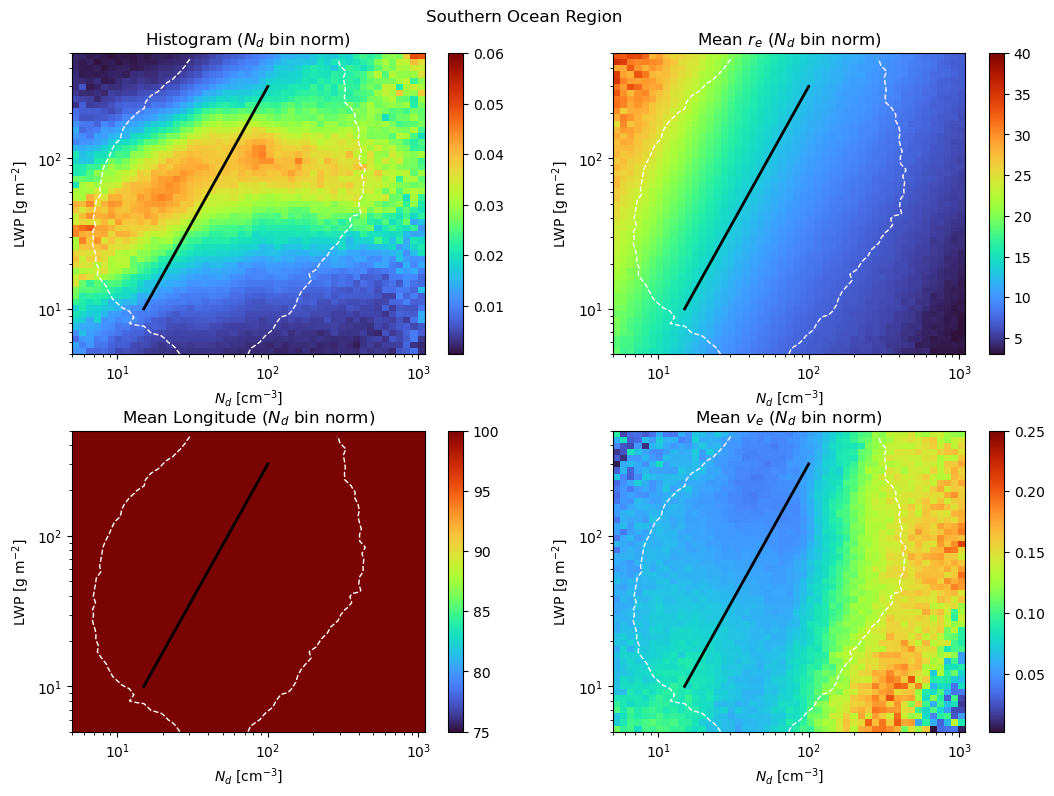

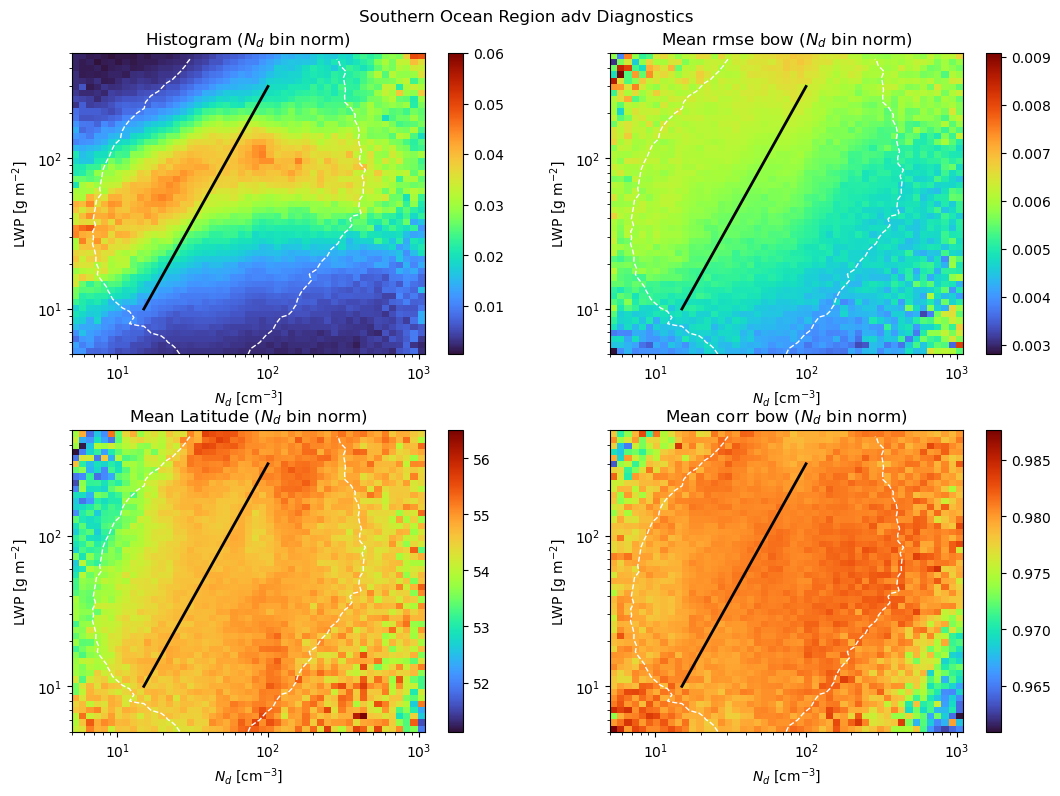

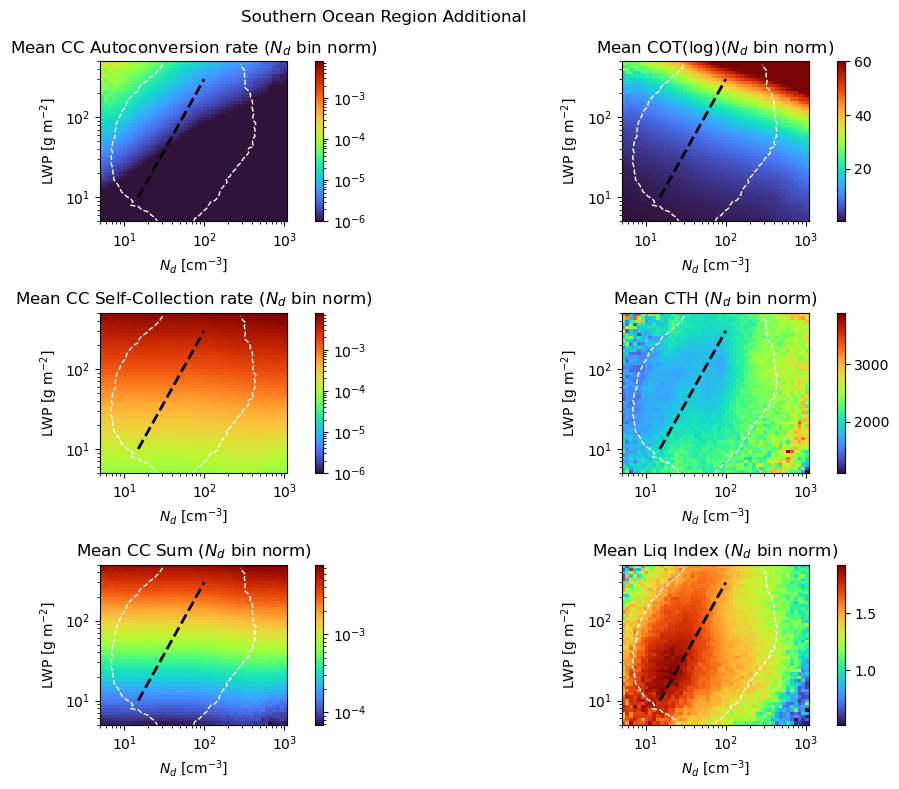

In [47]:
plot_GPC_LWP_Nd_hist('Southern Ocean Region', er, ev, er_RFT, ev_RFT, rmse_bow, corr_bow, cdnc, lwp, tau, cth, ctt, ctp, lindex, lat, lon, CC)

/tmp/ipykernel_448/1401461858.py:12: RuntimeWarning: divide by zero encountered in log10
  sum_tau_log,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(tau))
/tmp/ipykernel_448/1401461858.py:20: RuntimeWarning: divide by zero encountered in log10
  sum_CC_AU,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(-CC[0].magnitude))
/tmp/ipykernel_448/1401461858.py:21: RuntimeWarning: divide by zero encountered in log10
  sum_CC_SC,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(-CC[1].magnitude))


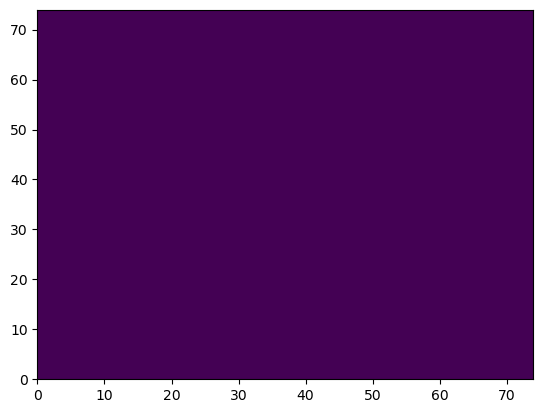

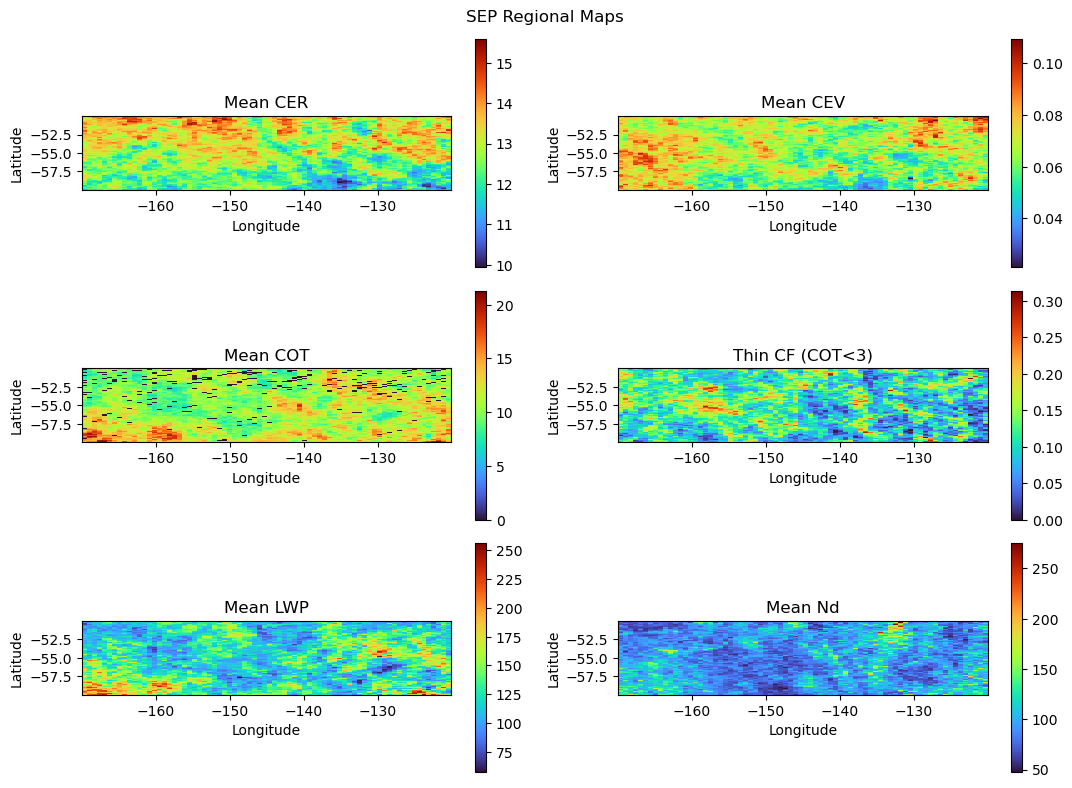

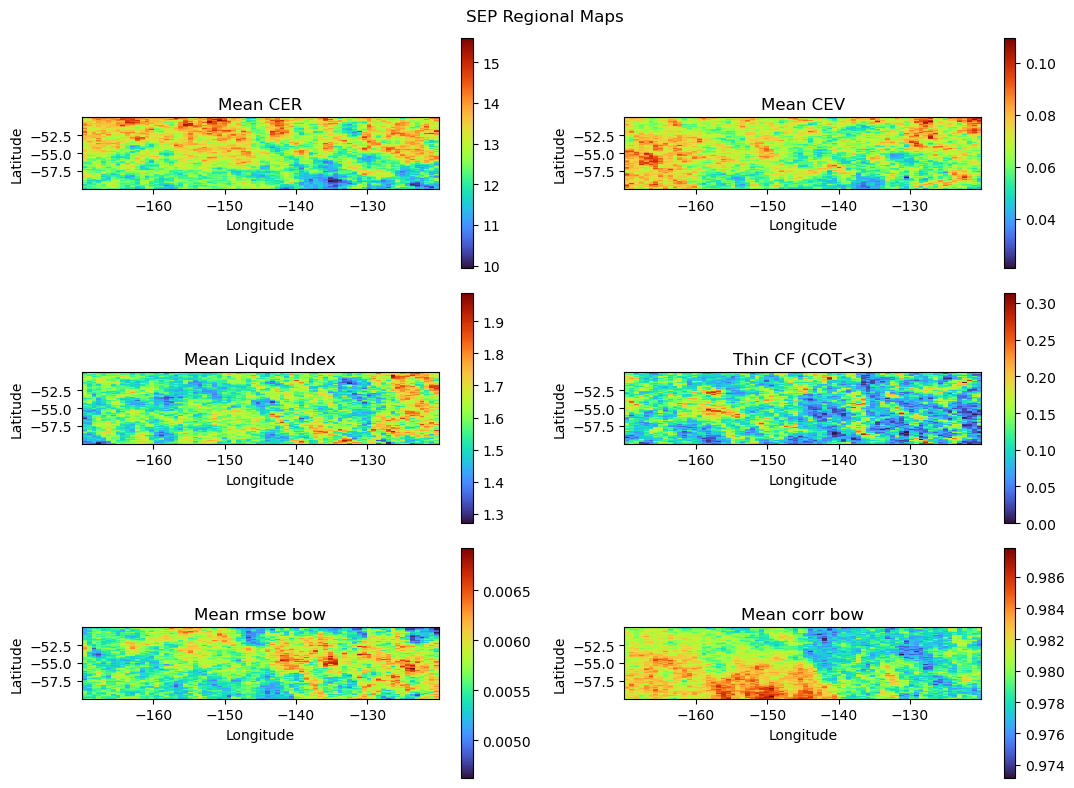

In [46]:
plot_GPC_L3maps('Southern Ocean Region', er, ev, er_RFT, ev_RFT, rmse_bow, corr_bow, cdnc, lwp, tau, cth, ctt, ctp, lindex, lat, lon, CC)

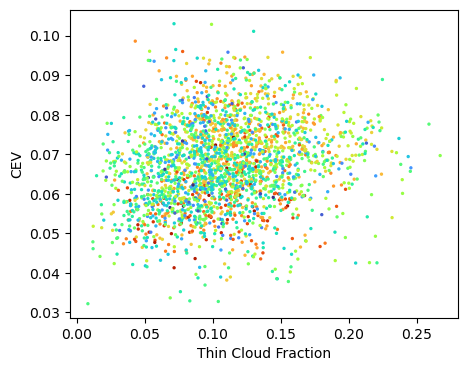

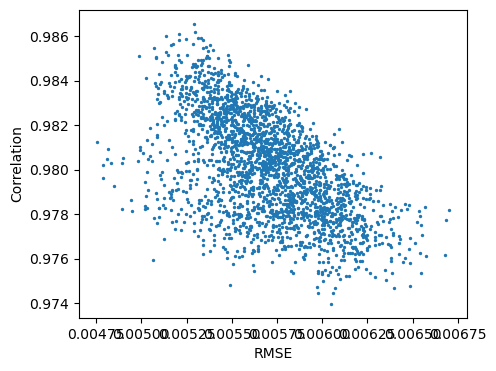

0.19951867612049423


In [62]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
mask=LM
cmap=plt.colormaps['turbo']
ax.scatter(mean_thin_frac[mask], mean_ve[mask],c=mean_corr_bow[mask], s=2, cmap=cmap)
ax.set_xlabel("Thin Cloud Fraction")
ax.set_ylabel("CEV")
plt.show()

fig,ax = plt.subplots(1,1,figsize=(5,4))
mask=LM
ax.scatter(mean_rmse_bow[mask], mean_corr_bow[mask], s=2)
ax.set_xlabel("RMSE")
ax.set_ylabel("Correlation")
plt.show()

corr=np.corrcoef(mean_thin_frac[mask].ravel(),mean_ve[mask].ravel())
correlation=corr[1,0]
print(correlation)


# SEP region

In [11]:
title='South-East Pacific Region'
bbox = (-110,-35,-70,-10)
#tspan = ("2024-09-29", "2025-09-29")

results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC_NRT",
    bounding_box=bbox,
    #temporal = tspan,
)
print(len(results))

paths = earthaccess.open(results)

er, ev, rmse_bow, corr_bow, cdnc, lwp, tau, cth, ctt, ctp, lindex, lat, lon, CC = gather_GPC(paths,bbox)

647


QUEUEING TASKS | :   0%|          | 0/647 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/647 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/647 [00:00<?, ?it/s]

PACE_OCI.20250701T175813.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T180313.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T180813.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T193633.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T194133.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T194633.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T211454.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T211954.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T170004.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T170504.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T183325.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T183825.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T184325.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T201145.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T201645.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T202145.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T173015.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T173515.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T174015.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T190836.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T19

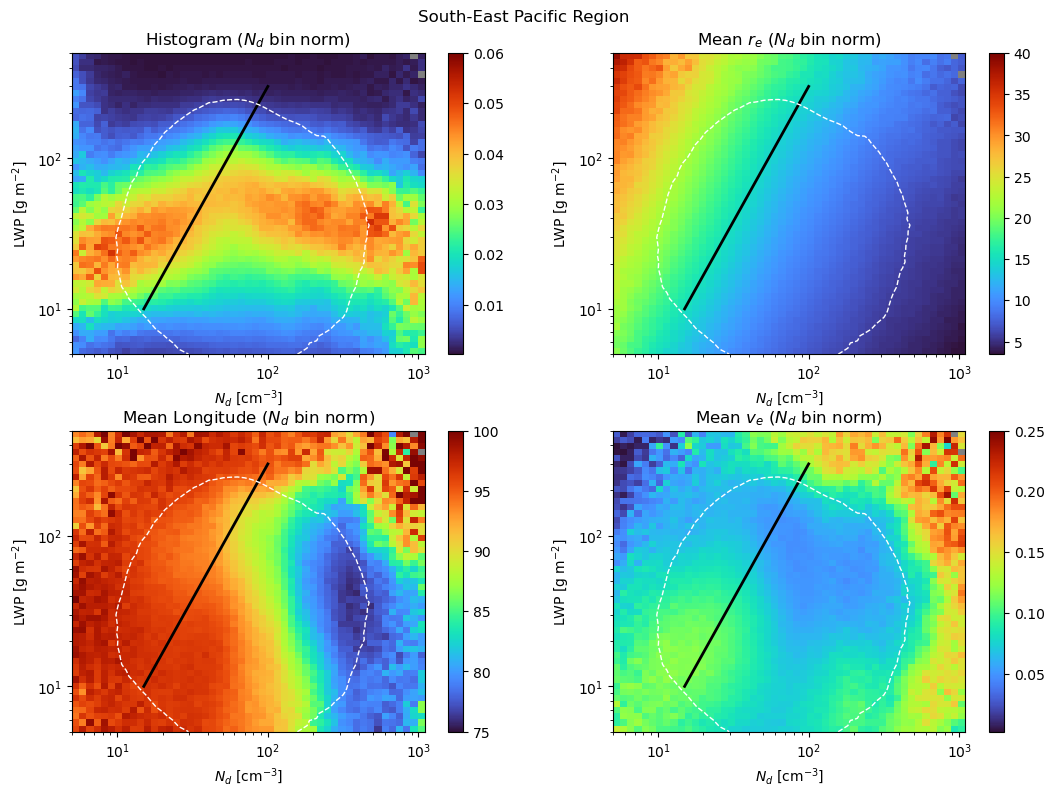

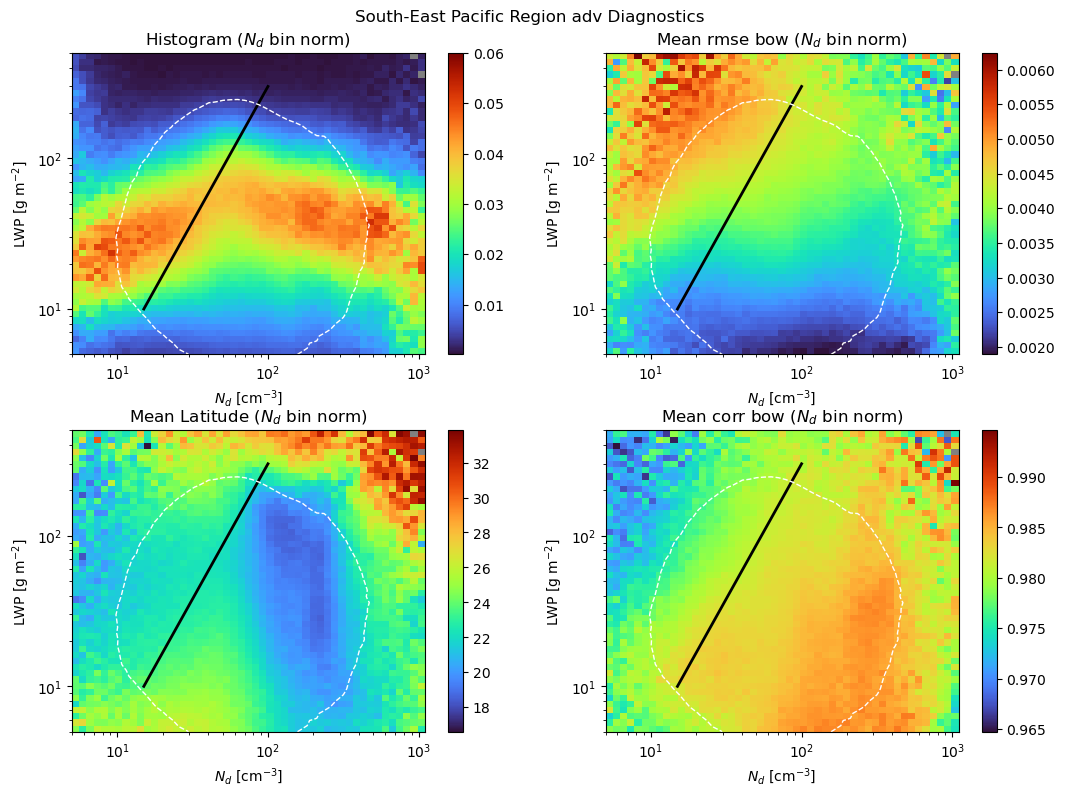

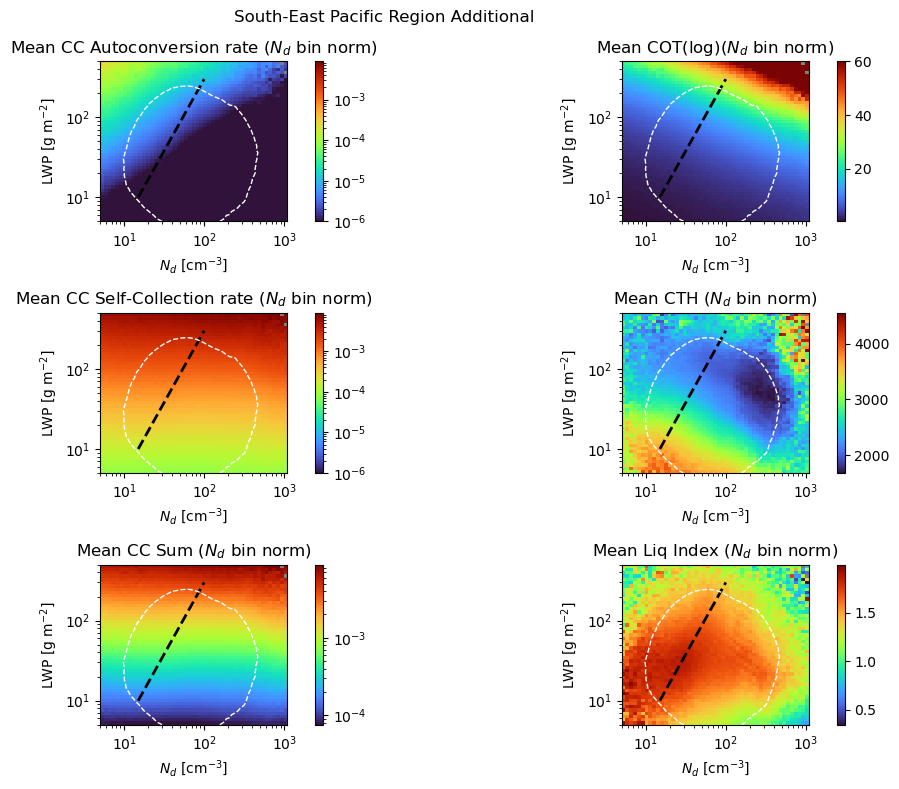

In [14]:
title='South-East Pacific Region'
plot_GPC_LWP_Nd_hist(title, er, ev, rmse_bow, corr_bow, cdnc, lwp, tau, cth, ctt, ctp, lindex, lat, lon, CC)

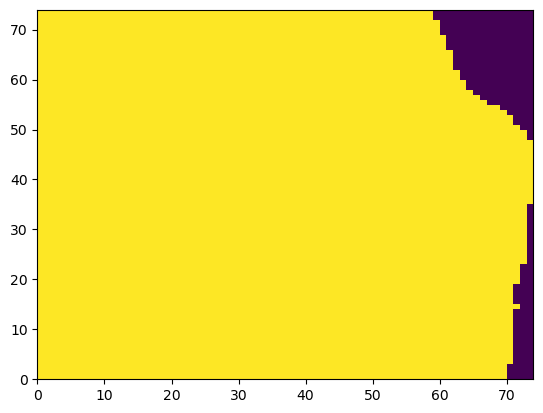

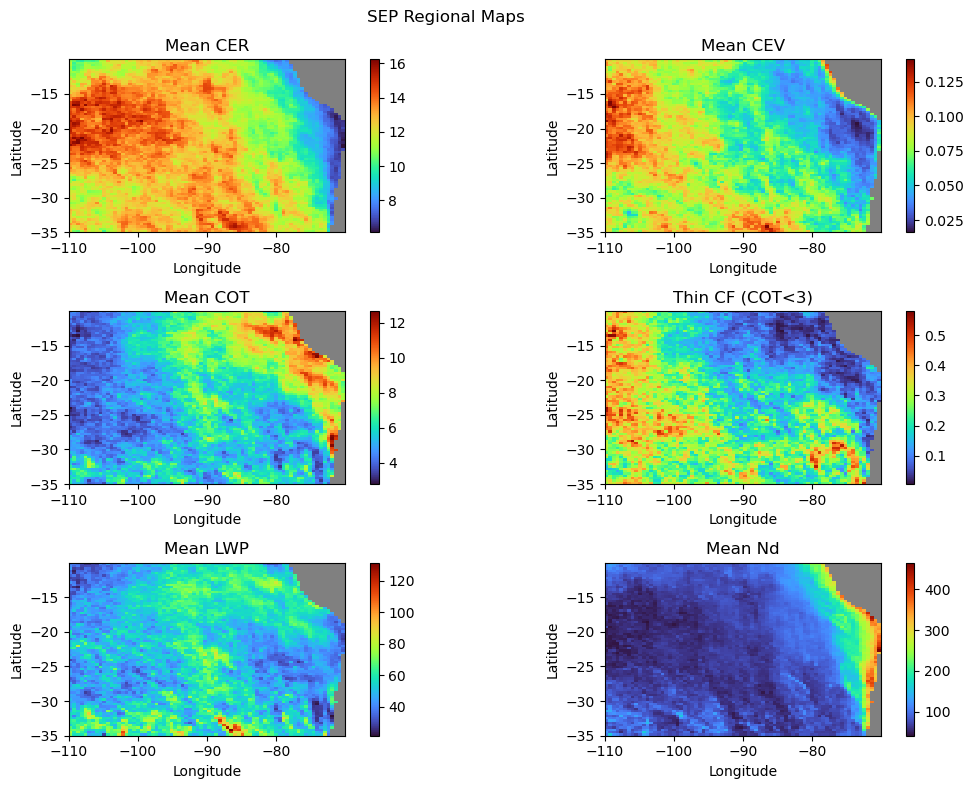

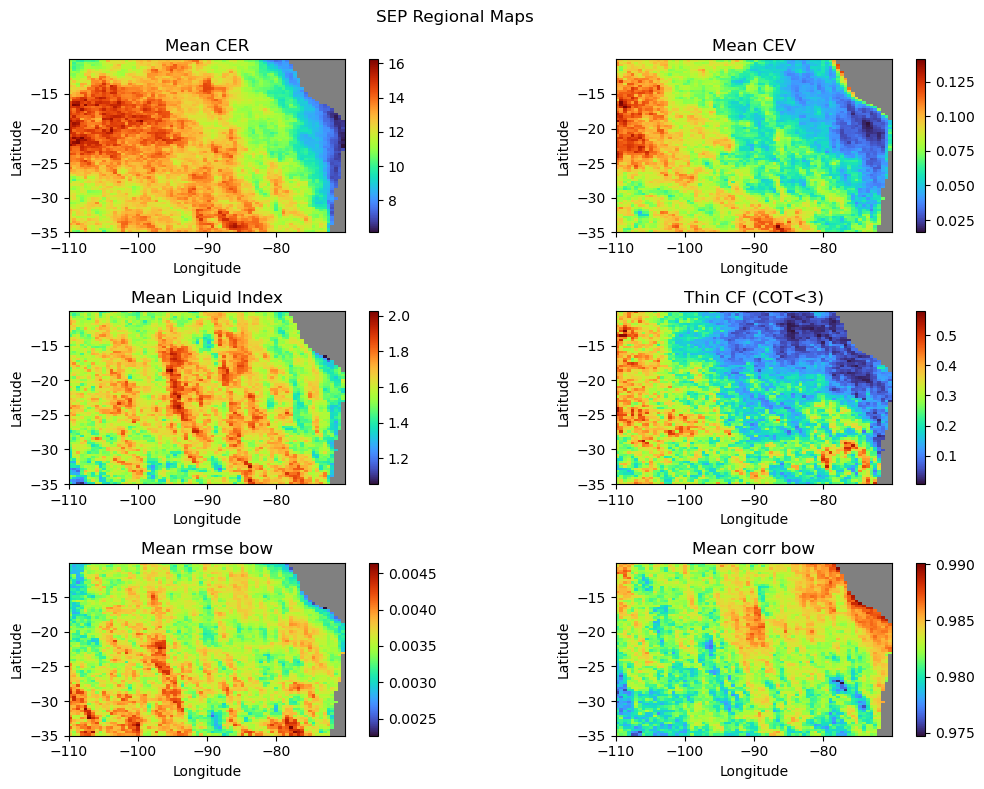

In [17]:
plot_GPC_L3maps(title, er, ev, rmse_bow, corr_bow, cdnc, lwp, tau, cth, ctt, ctp, lindex, lat, lon, CC)

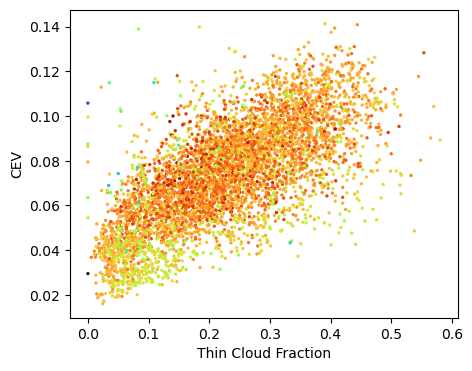

nan


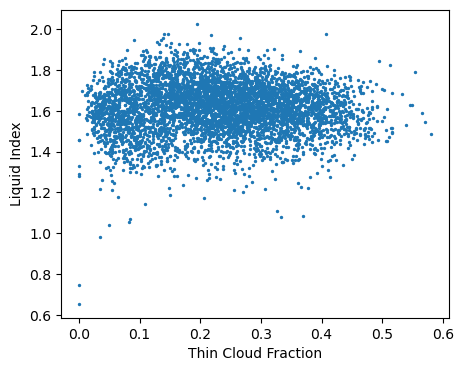

In [28]:
xbins = np.linspace(np.nanmin(lon),np.nanmax(lon),75) 
ybins = np.linspace(np.nanmin(lat),np.nanmax(lat),75) 
xbc=(xbins[0:-1]+xbins[1:])/2 #bin centers not edges
ybc=(ybins[0:-1]+ybins[1:])/2

counts, xedge, yedge = np.histogram2d(lon, lat, bins=(xbins, ybins))

sum_ve,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=ev)
sum_thin_frac,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=(tau<=3))
sum_lindex,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=lindex)

# Mean and (optional) standard deviation of z per bin
with np.errstate(divide='ignore', invalid='ignore'):
    mean_lindex = sum_lindex / counts
    mean_thin_frac = sum_thin_frac / counts
    mean_ve = sum_ve / counts


[lon_g,lat_g]=np.meshgrid(xbc,ybc)
LM = ~vec_is_over_land(lat_g,lon_g)  # True = land, False = ocean

fig,ax = plt.subplots(1,1,figsize=(5,4))
mask=LM
cmap=plt.colormaps['turbo']
ax.scatter(mean_thin_frac[mask], mean_ve[mask],c=mean_lindex[mask], s=2, cmap=cmap)
ax.set_xlabel("Thin Cloud Fraction")
ax.set_ylabel("CEV")
plt.show()

corr=np.corrcoef(mean_thin_frac[mask].ravel(),mean_ve[mask].ravel())
correlation=corr[1,0]
print(correlation)

fig,ax = plt.subplots(1,1,figsize=(5,4))
mask=LM
ax.scatter(mean_thin_frac[mask], mean_lindex[mask], s=2)
ax.set_xlabel("Thin Cloud Fraction")
ax.set_ylabel("Liquid Index")
plt.show()




In [30]:
ybins = np.linspace(np.nanmin(er),np.nanmax(er),50) 
xbins = np.linspace(np.nanmin(tau),np.nanmax(tau),50) 

counts, xedge, yedge = np.histogram2d(tau,er, bins=(xbins, ybins))
counts, xedge, yedge = np.histogram2d(tau,er, bins=(xbins, ybins))
sum_re,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=er)
sum_ve,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=ev)
#sum_re_RFT,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=er_RFT)
#sum_ve_RFT,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=ev_RFT)
sum_tau,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=tau)
sum_tau_log,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=np.log10(tau))
sum_LWP,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=lwp)
sum_Nd,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=cdnc)
sum_CTH,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=cth)
sum_lindex,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=lindex)
sum_lon,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=np.abs(lon))
sum_lat,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=np.abs(lat))
sum_thin_frac,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=(tau<=3))
sum_CC_AU,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=np.log10(-CC[0].magnitude))
sum_CC_SC,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=np.log10(-CC[1].magnitude))
sum_rmse_bow,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=rmse_bow)
sum_corr_bow,   _, _ = np.histogram2d(tau,er, bins=(xbins, ybins), weights=corr_bow)

# Mean and (optional) standard deviation of z per bin
with np.errstate(divide='ignore', invalid='ignore'):
    mean_re = sum_re / counts
    mean_ve = sum_ve / counts
    mean_re_RFT = sum_re_RFT / counts
    mean_ve_RFT = sum_ve_RFT / counts
    mean_tau = sum_tau / counts
    mean_tau_log = 10**(sum_tau_log / counts)
    mean_LWP = sum_LWP / counts
    mean_Nd = sum_Nd / counts
    mean_CTH = sum_CTH / counts
    mean_lindex = sum_lindex / counts
    mean_thin_frac = sum_thin_frac / counts
    mean_lon = sum_lon / counts
    mean_lat = sum_lat / counts
    mean_CC_AU = 10**(sum_CC_AU / counts)
    mean_CC_SC = 10**(sum_CC_SC / counts)
    mean_rmse_bow = sum_rmse_bow / counts    
    mean_corr_bow = sum_corr_bow / counts


h_norm = counts/np.nansum(counts)
h_norm=np.transpose(h_norm)
h_norm[h_norm == 0] = np.nan

fig,ax = plt.subplots(3,2,figsize=(11, 8))
cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
plt.suptitle('SEP Microphysical Ret Grid')

titles={}
ims={}

titles[(0,0)] = 'Histogram'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,h_norm,cmap=cmap,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=np.nanmax(h_norm)))
titles[(0,1)] = 'Mean CEV'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_ve.T,cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean COT'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_lindex.T,cmap=cmap)
titles[(1,1)] = 'Mean CTH'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_CTH.T,cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(2,0)] = 'Mean LWP'
ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,mean_LWP,cmap=cmap)
titles[(2,1)] = 'Mean Nd'
ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,mean_Nd.T,cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))


for i in range(3):
    for j in range(2):
        #ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        #ax[i,j].set_yscale('log')
        #ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("COT")
        ax[i,j].set_ylabel("CER")
        ax[i,j].set_title(titles[i,j])
        #ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])

plt.tight_layout()
plt.show()

NameError: name 'sum_re_RFT' is not defined

# NEP Region

In [63]:
bbox = (-140,-40,-120,-25)

results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC_NRT",
    bounding_box=bbox,
)
print(len(results))

paths = earthaccess.open(results)

337


QUEUEING TASKS | :   0%|          | 0/337 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/337 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/337 [00:00<?, ?it/s]

In [64]:
er = []
er_RFT = []
ev = []
ev_RFT = []
cdnc = []
lwp = []
tau = []
lindex = []
cth = []
ctp = []
ctt = []
lat = []
lon = []
rmse_bow = []
corr_bow = []

count = 0
counterr = 0

for p in paths:
    try: 
        ds = open_L2_CLOUD_GPC(p,bbox)
        across_dim = ds.latitude.dims[-1]  # last dim of lat/vars is across-track
        ds = ds.isel({across_dim: slice(0, 311)})  # drop columns > 310 up front
        mask = ~np.isnan(ds.cloud_bow_droplet_effective_radius.data.flatten()) & ~np.isnan(ds.cloud_bow_droplet_effective_variance.data.flatten()) & ~np.isnan(ds.cloud_bow_droplet_number_concentration_adiabatic.data.flatten()) & ~np.isnan(ds.cloud_bow_liquid_water_path.data.flatten())        
        er = np.concatenate((er,ds.cloud_bow_droplet_effective_radius.data.flatten()[mask]))
        ev = np.concatenate((ev,ds.cloud_bow_droplet_effective_variance.data.flatten()[mask]))
        er_RFT = np.concatenate((er_RFT,ds.cloud_rft_droplet_effective_radius_mode_0.data.flatten()[mask]))
        ev_RFT = np.concatenate((ev_RFT,ds.cloud_rft_droplet_effective_variance_mode_0.data.flatten()[mask]))
        rmse_bow =  np.concatenate((rmse_bow,ds.cloud_bow_rms.data.flatten()[mask]))
        corr_bow =  np.concatenate((corr_bow,ds.cloud_bow_fit_correlation.data.flatten()[mask]))    
        cdnc = np.concatenate((cdnc,ds.cloud_bow_droplet_number_concentration_adiabatic.data.flatten()[mask]))
        lwp = np.concatenate((lwp,ds.cloud_bow_liquid_water_path.data.flatten()[mask]))
        tau = np.concatenate((tau,ds.cloud_optical_thickness.data.flatten()[mask]))
        cth = np.concatenate((cth,ds.cloud_top_altitude.data.flatten()[mask]))
        ctt = np.concatenate((ctt,ds.cloud_top_temperature.data.flatten()[mask]))
        ctp = np.concatenate((ctp,ds.cloud_top_pressure.data.flatten()[mask]))
        
        lindex = np.concatenate((lindex,ds.cloud_liquid_index.data.flatten()[mask]))
        
        lat = np.concatenate((lat,ds.latitude.data.flatten()[mask]))
        lon = np.concatenate((lon,ds.longitude.data.flatten()[mask]))
        
        print(ds.aux_file)
        del(ds)
    except:
        print('I had an error', count)
    count += 1

CC=CC_growth_rates_retrieval(er,ev,tau,ctt,ctp,Cw=0.0020, fad=0.7, Qext = 2.0)


PACE_OCI.20250701T211454.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T211954.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T225315.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T225815.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T215006.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T215506.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T232827.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T204657.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T205157.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T222518.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T223018.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T212209.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T212709.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T230030.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T230530.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250705T201900.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250705T202400.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250705T215720.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250705T220220.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250705T233541.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250706T20

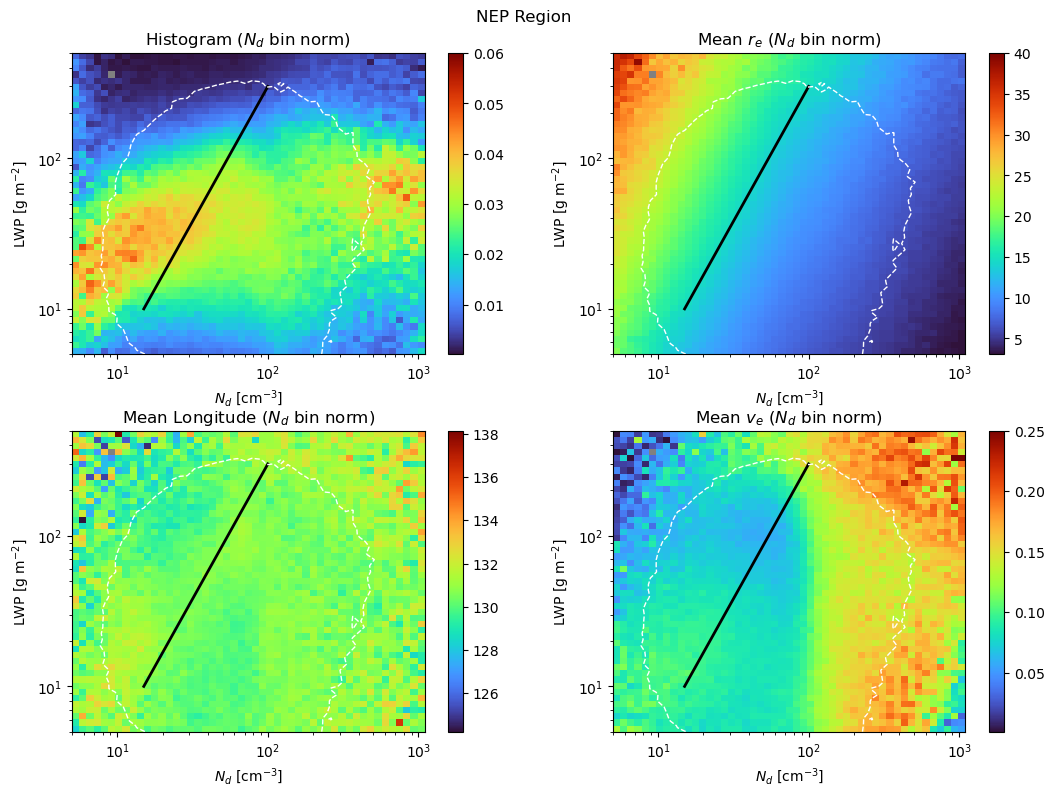

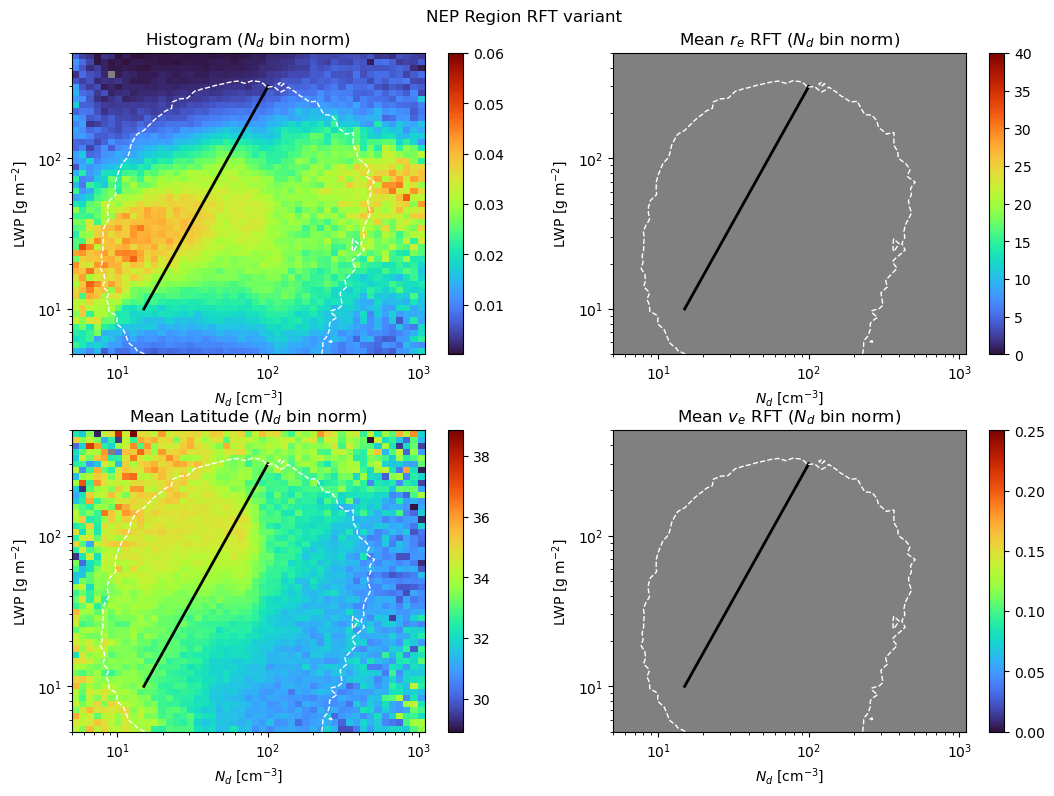

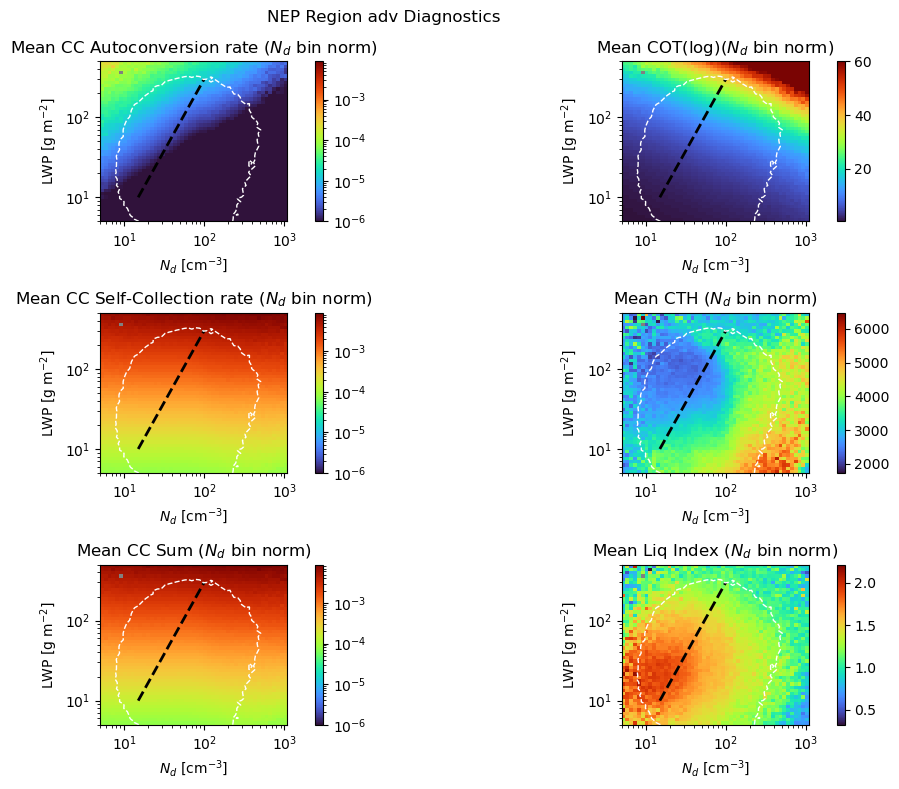

In [65]:
xbins = np.logspace(np.log10(5),np.log10(1100),50) # <- make a range from 10**xmin to 10**xmax ## Selected to sample SEP 95%
ybins = np.logspace(np.log10(5),np.log10(500),50) # <- make a range from 10**ymin to 10**ymax ## Selected to sample SEP 95%
counts, xedge, yedge = np.histogram2d(cdnc, lwp, bins=(xbins, ybins))
sum_re,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=er)
sum_ve,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=ev)
sum_re_RFT,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=er_RFT)
sum_ve_RFT,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=ev_RFT)
sum_tau,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=tau)
sum_tau_log,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.log10(tau))
sum_CTH,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=cth)
sum_lindex,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=lindex)
sum_lon,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.abs(lon))
sum_lat,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.abs(lat))
sum_thin_frac,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=(tau<=3))
sum_CC_AU,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=-CC[0].magnitude)
sum_CC_SC,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=-CC[1].magnitude)


# Mean and (optional) standard deviation of z per bin
with np.errstate(divide='ignore', invalid='ignore'):
    mean_re = sum_re / counts
    mean_ve = sum_ve / counts
    mean_re_RFT = sum_re_RFT / counts
    mean_ve_RFT = sum_ve_RFT / counts
    mean_tau = sum_tau / counts
    mean_tau_log = 10**(sum_tau_log / counts)
    mean_CTH = sum_CTH / counts
    mean_lindex = sum_lindex / counts
    mean_thin_frac = sum_thin_frac / counts
    mean_lon = sum_lon / counts
    mean_lat = sum_lat / counts
    mean_CC_AU = sum_CC_AU / counts
    mean_CC_SC = sum_CC_SC / counts
    
counts_plt=counts/np.sum(counts)
counts_plt=counts_plt.T
counts_plt[counts_plt == 0] = np.nan

h_norm = counts/counts.sum(axis=1,keepdims=True)
h_norm=np.transpose(h_norm)
h_norm[h_norm == 0] = np.nan

hist_sorted = np.sort(counts.ravel())
cumulative_sum = np.cumsum(hist_sorted)
total_count = cumulative_sum[-1]
#hist_levels=np.zeros(3,dtype=np.float64)
#for i in range(3):
#    prob = chi2.cdf([3**2, 2**2, 1**2], df=2)
    
prob=0.95
hist_levels = hist_sorted[cumulative_sum >= total_count * (1 - prob)][0]

##############
fig,ax = plt.subplots(2,2,figsize=(11, 8))
plt.suptitle('NEP Region')

cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
titles={}
ims={}

titles[(0,0)] = 'Histogram ($N_d$ bin norm)'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,h_norm,cmap=cmap,vmax=0.06)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(0,1)] = 'Mean $r_e$ ($N_d$ bin norm)'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_re.T,cmap=cmap,vmax=40)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean Longitude ($N_d$ bin norm)'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_lon.T,cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,1)] = 'Mean $v_e$ ($N_d$ bin norm)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_ve.T,cmap=cmap,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))

for i in range(2):
    for j in range(2):
        ax[i,j].plot([15,100], [10,300], color='black', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        ax[i,j].set_yscale('log')
        ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("$N_d$ [cm$^{-3}$]")
        ax[i,j].set_ylabel("LWP [g m$^{-2}$]")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])
plt.tight_layout()
plt.show()


#####################
fig,ax = plt.subplots(2,2,figsize=(11, 8))
plt.suptitle('NEP Region RFT variant')

cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
titles={}
ims={}

titles[(0,0)] = 'Histogram ($N_d$ bin norm)'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,h_norm,cmap=cmap,vmax=0.06)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(0,1)] = 'Mean $r_e$ RFT ($N_d$ bin norm)'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_re_RFT.T,cmap=cmap,vmax=40)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean Latitude ($N_d$ bin norm)'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_lat.T,cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,1)] = 'Mean $v_e$ RFT ($N_d$ bin norm)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_ve_RFT.T,cmap=cmap,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))

for i in range(2):
    for j in range(2):
        ax[i,j].plot([15,100], [10,300], color='black', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        ax[i,j].set_yscale('log')
        ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("$N_d$ [cm$^{-3}$]")
        ax[i,j].set_ylabel("LWP [g m$^{-2}$]")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])


plt.tight_layout()
plt.show()

##############
fig,ax = plt.subplots(3,2,figsize=(11, 8))
cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
plt.suptitle('NEP Region adv Diagnostics')

titles={}
ims={}

titles[(0,0)] = 'Mean CC Autoconversion rate ($N_d$ bin norm)'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,mean_CC_AU.T,cmap=cmap,norm=LogNorm(vmin=1e-6, vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))#norm=LogNorm(vmin=np.nanmin(np.stack([mean_CC_AU,mean_CC_SC])), vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(0,1)] = 'Mean COT(log)($N_d$ bin norm)'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_tau_log.T,cmap=cmap,vmax=60)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean CC Self-Collection rate ($N_d$ bin norm)'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_CC_SC.T,cmap=cmap,norm=LogNorm(vmin=1e-6, vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(1,1)] = 'Mean CTH ($N_d$ bin norm)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_CTH.T,cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(2,0)] = 'Mean CC Sum ($N_d$ bin norm)'
ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,mean_CC_AU.T+mean_CC_SC.T,cmap=cmap,norm=LogNorm(vmin=1e-6, vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(2,1)] = 'Mean Liq Index ($N_d$ bin norm)'
ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,mean_lindex.T,cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))


for i in range(3):
    for j in range(2):
        ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        ax[i,j].set_yscale('log')
        ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("$N_d$ [cm$^{-3}$]")
        ax[i,j].set_ylabel("LWP [g m$^{-2}$]")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])



plt.tight_layout()
plt.show()

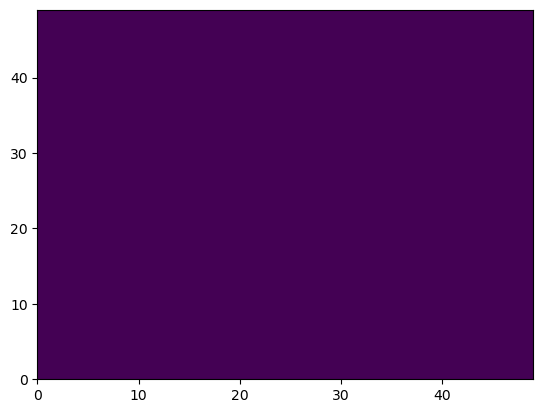

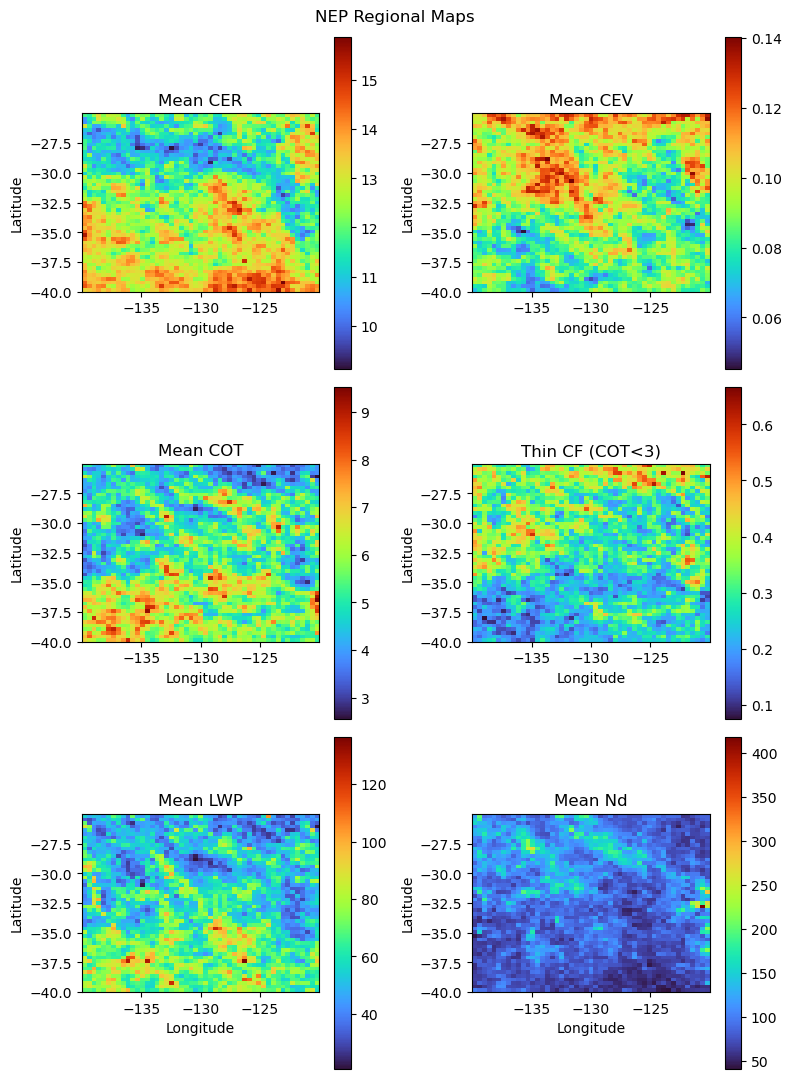

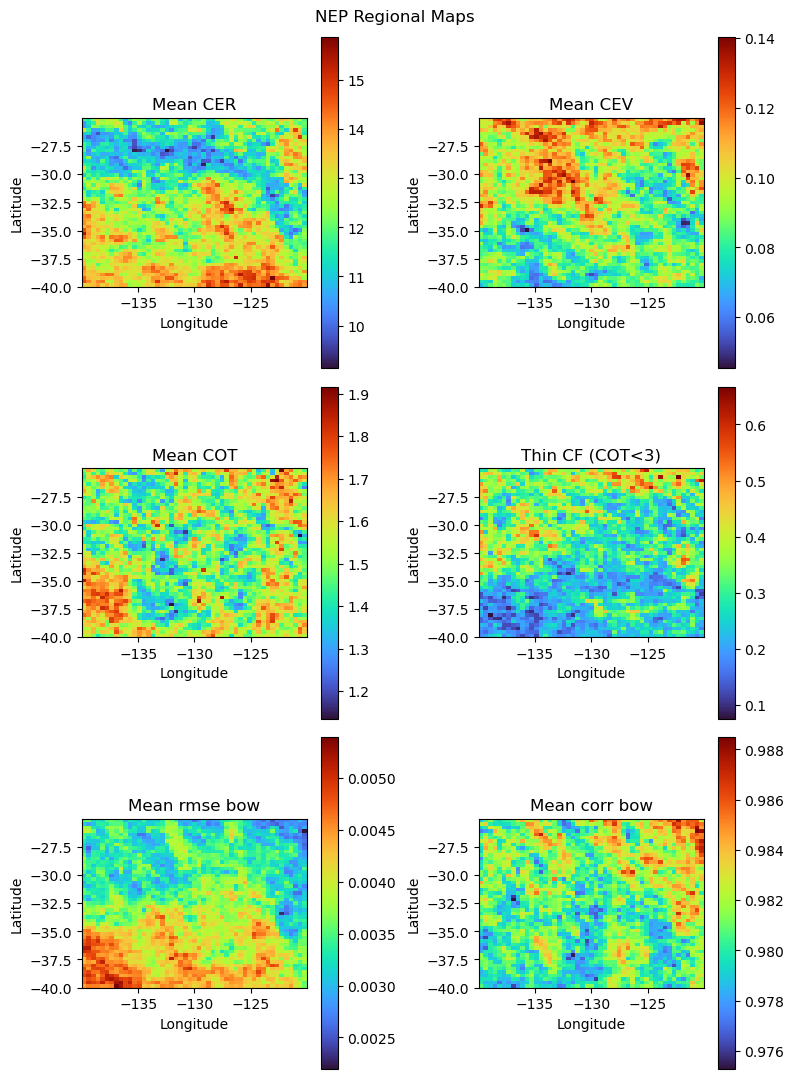

In [66]:
xbins = np.linspace(np.nanmin(lon),np.nanmax(lon),50) 
ybins = np.linspace(np.nanmin(lat),np.nanmax(lat),50) 

counts, xedge, yedge = np.histogram2d(lon, lat, bins=(xbins, ybins))
counts, xedge, yedge = np.histogram2d(lon, lat, bins=(xbins, ybins))
sum_re,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=er)
sum_ve,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=ev)
sum_re_RFT,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=er_RFT)
sum_ve_RFT,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=ev_RFT)
sum_tau,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=tau)
sum_tau_log,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(tau))
sum_LWP,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=lwp)
sum_Nd,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=cdnc)
sum_CTH,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=cth)
sum_lindex,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=lindex)
sum_lon,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.abs(lon))
sum_lat,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.abs(lat))
sum_thin_frac,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=(tau<=3))
sum_CC_AU,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(-CC[0].magnitude))
sum_CC_SC,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(-CC[1].magnitude))
sum_rmse_bow,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=rmse_bow)
sum_corr_bow,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=corr_bow)


# Mean and (optional) standard deviation of z per bin
with np.errstate(divide='ignore', invalid='ignore'):
    mean_re = sum_re / counts
    mean_ve = sum_ve / counts
    mean_re_RFT = sum_re_RFT / counts
    mean_ve_RFT = sum_ve_RFT / counts
    mean_tau = sum_tau / counts
    mean_tau_log = 10**(sum_tau_log / counts)
    mean_LWP = sum_LWP / counts
    mean_Nd = sum_Nd / counts
    mean_CTH = sum_CTH / counts
    mean_lindex = sum_lindex / counts
    mean_thin_frac = sum_thin_frac / counts
    mean_lon = sum_lon / counts
    mean_lat = sum_lat / counts
    mean_CC_AU = 10**(sum_CC_AU / counts)
    mean_CC_SC = 10**(sum_CC_SC / counts)
    mean_rmse_bow = sum_rmse_bow / counts    
    mean_corr_bow = sum_corr_bow / counts


xbc=(xbins[0:-1]+xbins[1:])/2 #bin centers not edges
ybc=(ybins[0:-1]+ybins[1:])/2
[lon_g,lat_g]=np.meshgrid(xbc,ybc)

LM = ~vec_is_over_land(lat_g,lon_g)  # True = land, False = ocean
plt.pcolormesh(LM)
plt.show()

fig,ax = plt.subplots(3,2,figsize=(8, 11))
cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
plt.suptitle('NEP Regional Maps')

titles={}
ims={}

titles[(0,0)] = 'Mean CER'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,np.where(LM, mean_re.T, np.nan),cmap=cmap)#norm=LogNorm(vmin=np.nanmin(np.stack([mean_CC_AU,mean_CC_SC])), vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(0,1)] = 'Mean CEV'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,np.where(LM, mean_ve.T, np.nan),cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean COT'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,np.where(LM, mean_tau_log.T, np.nan),cmap=cmap)
titles[(1,1)] = 'Thin CF (COT<3)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,np.where(LM, mean_thin_frac.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(2,0)] = 'Mean LWP'
ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,np.where(LM, mean_LWP.T, np.nan),cmap=cmap)
titles[(2,1)] = 'Mean Nd'
ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,np.where(LM, mean_Nd.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))


for i in range(3):
    for j in range(2):
        #ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        #ax[i,j].set_yscale('log')
        #ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("Longitude")
        ax[i,j].set_ylabel("Latitude")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])

plt.tight_layout()
plt.show()

fig,ax = plt.subplots(3,2,figsize=(8, 11))
cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
plt.suptitle('NEP Regional Maps')

titles={}
ims={}

titles[(0,0)] = 'Mean CER'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,np.where(LM, mean_re.T, np.nan),cmap=cmap)#norm=LogNorm(vmin=np.nanmin(np.stack([mean_CC_AU,mean_CC_SC])), vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(0,1)] = 'Mean CEV'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,np.where(LM, mean_ve.T, np.nan),cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean Liq Index'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,np.where(LM, mean_lindex.T, np.nan),cmap=cmap)
titles[(1,1)] = 'Thin CF (COT<3)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,np.where(LM, mean_thin_frac.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(2,0)] = 'Mean rmse bow'
ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,np.where(LM, mean_rmse_bow.T, np.nan),cmap=cmap)
titles[(2,1)] = 'Mean corr bow'
ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,np.where(LM, mean_corr_bow.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))


for i in range(3):
    for j in range(2):
        #ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        #ax[i,j].set_yscale('log')
        #ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("Longitude")
        ax[i,j].set_ylabel("Latitude")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])

plt.tight_layout()
plt.show()


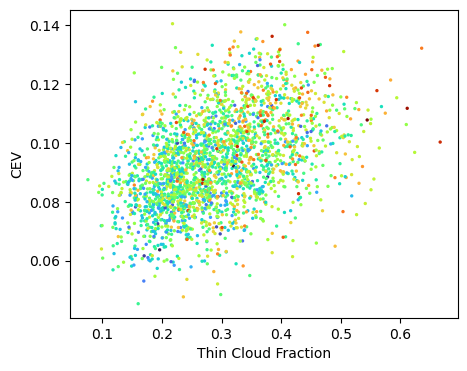

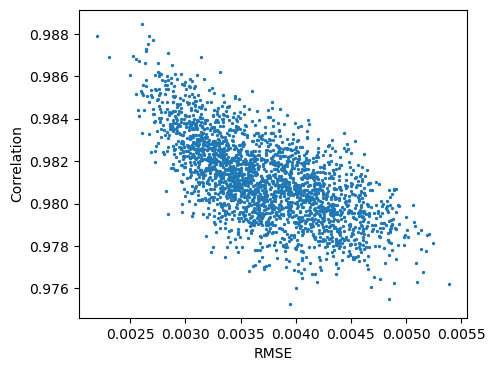

0.4389926443833222


In [67]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
mask=LM
cmap=plt.colormaps['turbo']
ax.scatter(mean_thin_frac[mask], mean_ve[mask],c=mean_corr_bow[mask], s=2, cmap=cmap)
ax.set_xlabel("Thin Cloud Fraction")
ax.set_ylabel("CEV")
plt.show()

fig,ax = plt.subplots(1,1,figsize=(5,4))
mask=LM
ax.scatter(mean_rmse_bow[mask], mean_corr_bow[mask], s=2)
ax.set_xlabel("RMSE")
ax.set_ylabel("Correlation")
plt.show()

corr=np.corrcoef(mean_thin_frac[mask].ravel(),mean_ve[mask].ravel())
correlation=corr[1,0]
print(correlation)

# SEA Region

In [68]:
#bbox = (-110,-35,-70,-10)
bbox = (-20,-25,12,0)   #W,S,E,N = bounding_box


results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC_NRT",
    bounding_box=bbox,
)
print(len(results))

paths = earthaccess.open(results)

468


QUEUEING TASKS | :   0%|          | 0/468 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/468 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/468 [00:00<?, ?it/s]

In [69]:
er = []
er_RFT = []
ev = []
ev_RFT = []
cdnc = []
lwp = []
tau = []
lindex = []
cth = []
ctp = []
ctt = []
lat = []
lon = []
rmse_bow = []
corr_bow = []

count = 0
counterr = 0

for p in paths:
    try: 
        ds = open_L2_CLOUD_GPC(p,bbox)
        across_dim = ds.latitude.dims[-1]  # last dim of lat/vars is across-track
        ds = ds.isel({across_dim: slice(0, 311)})  # drop columns > 310 up front
        mask = ~np.isnan(ds.cloud_bow_droplet_effective_radius.data.flatten()) & ~np.isnan(ds.cloud_bow_droplet_effective_variance.data.flatten()) & ~np.isnan(ds.cloud_bow_droplet_number_concentration_adiabatic.data.flatten()) & ~np.isnan(ds.cloud_bow_liquid_water_path.data.flatten())        
        er = np.concatenate((er,ds.cloud_bow_droplet_effective_radius.data.flatten()[mask]))
        ev = np.concatenate((ev,ds.cloud_bow_droplet_effective_variance.data.flatten()[mask]))
        er_RFT = np.concatenate((er_RFT,ds.cloud_rft_droplet_effective_radius_mode_0.data.flatten()[mask]))
        ev_RFT = np.concatenate((ev_RFT,ds.cloud_rft_droplet_effective_variance_mode_0.data.flatten()[mask]))
        rmse_bow =  np.concatenate((rmse_bow,ds.cloud_bow_rms.data.flatten()[mask]))
        corr_bow =  np.concatenate((corr_bow,ds.cloud_bow_fit_correlation.data.flatten()[mask]))    
        cdnc = np.concatenate((cdnc,ds.cloud_bow_droplet_number_concentration_adiabatic.data.flatten()[mask]))
        lwp = np.concatenate((lwp,ds.cloud_bow_liquid_water_path.data.flatten()[mask]))
        tau = np.concatenate((tau,ds.cloud_optical_thickness.data.flatten()[mask]))
        cth = np.concatenate((cth,ds.cloud_top_altitude.data.flatten()[mask]))
        ctt = np.concatenate((ctt,ds.cloud_top_temperature.data.flatten()[mask]))
        ctp = np.concatenate((ctp,ds.cloud_top_pressure.data.flatten()[mask]))
        
        lindex = np.concatenate((lindex,ds.cloud_liquid_index.data.flatten()[mask]))
        
        lat = np.concatenate((lat,ds.latitude.data.flatten()[mask]))
        lon = np.concatenate((lon,ds.longitude.data.flatten()[mask]))
        
        print(ds.aux_file)
        del(ds)
    except:
        print('I had an error', count)
    count += 1

CC=CC_growth_rates_retrieval(er,ev,tau,ctt,ctp,Cw=0.0020, fad=0.7, Qext = 2.0)


PACE_OCI.20250701T112950.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T113450.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T130810.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T131310.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T144631.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250701T145131.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T120502.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T121002.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T134322.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T134822.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250702T152143.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T124013.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T124513.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T141834.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250703T142334.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T113704.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T114204.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T131525.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T132025.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T145346.L1C.ANC.V3_0.5km.NRT.nc
PACE_OCI.20250704T14

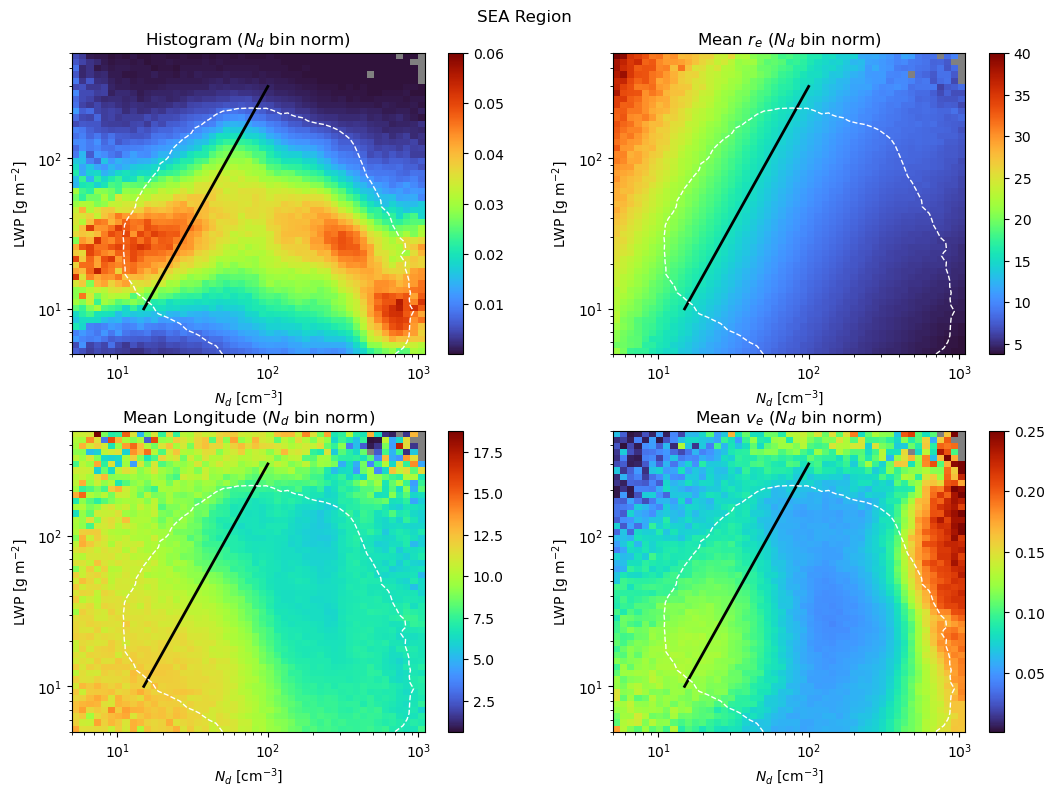

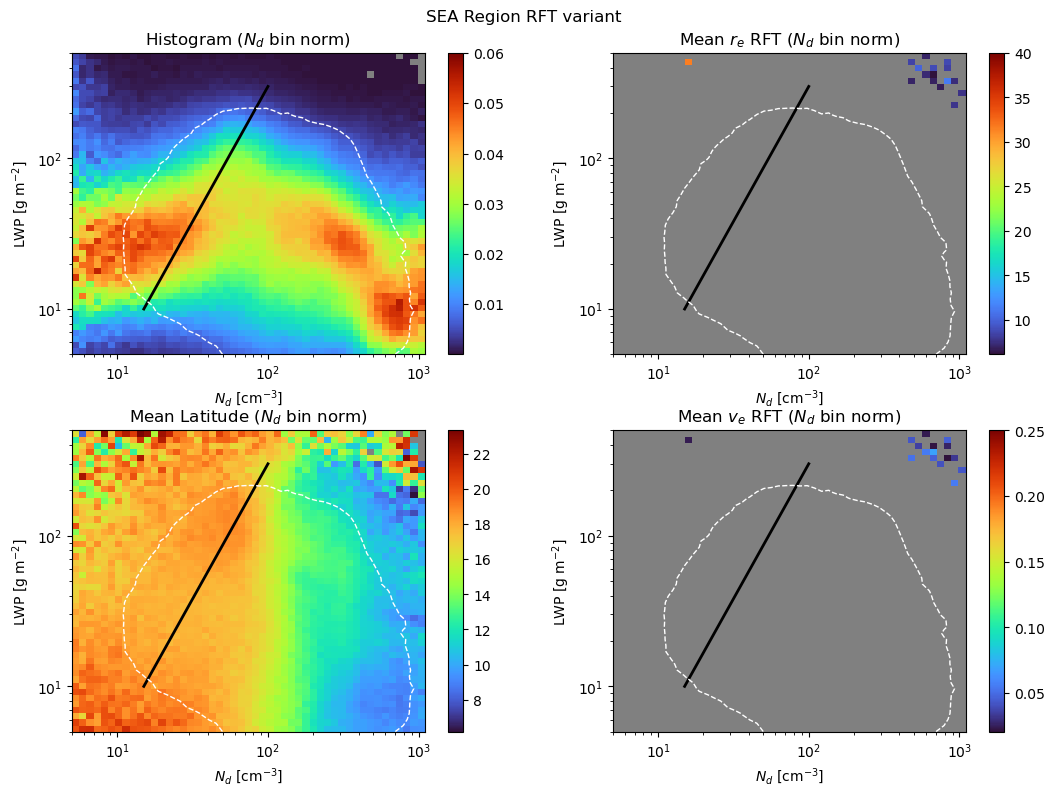

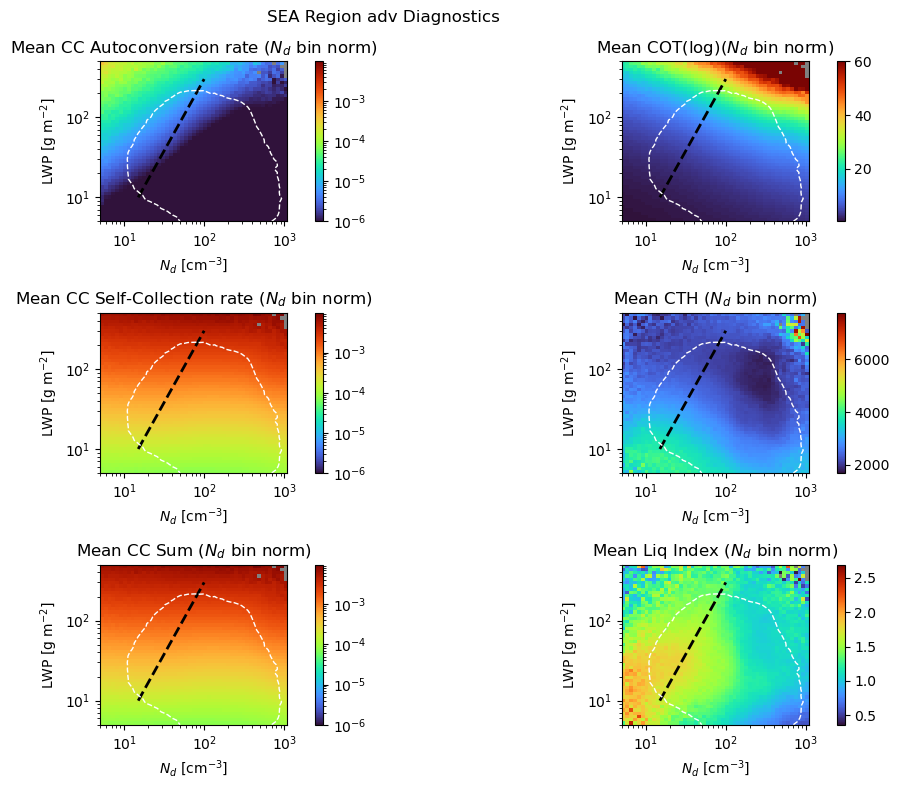

In [70]:
xbins = np.logspace(np.log10(5),np.log10(1100),50) # <- make a range from 10**xmin to 10**xmax ## Selected to sample SEP 95%
ybins = np.logspace(np.log10(5),np.log10(500),50) # <- make a range from 10**ymin to 10**ymax ## Selected to sample SEP 95%
counts, xedge, yedge = np.histogram2d(cdnc, lwp, bins=(xbins, ybins))
sum_re,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=er)
sum_ve,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=ev)
sum_re_RFT,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=er_RFT)
sum_ve_RFT,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=ev_RFT)
sum_tau,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=tau)
sum_tau_log,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.log10(tau))
sum_CTH,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=cth)
sum_lindex,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=lindex)
sum_lon,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.abs(lon))
sum_lat,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=np.abs(lat))
sum_thin_frac,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=(tau<=3))
sum_CC_AU,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=-CC[0].magnitude)
sum_CC_SC,   _, _ = np.histogram2d(cdnc, lwp, bins=(xbins, ybins), weights=-CC[1].magnitude)


# Mean and (optional) standard deviation of z per bin
with np.errstate(divide='ignore', invalid='ignore'):
    mean_re = sum_re / counts
    mean_ve = sum_ve / counts
    mean_re_RFT = sum_re_RFT / counts
    mean_ve_RFT = sum_ve_RFT / counts
    mean_tau = sum_tau / counts
    mean_tau_log = 10**(sum_tau_log / counts)
    mean_CTH = sum_CTH / counts
    mean_lindex = sum_lindex / counts
    mean_thin_frac = sum_thin_frac / counts
    mean_lon = sum_lon / counts
    mean_lat = sum_lat / counts
    mean_CC_AU = sum_CC_AU / counts
    mean_CC_SC = sum_CC_SC / counts
    
counts_plt=counts/np.sum(counts)
counts_plt=counts_plt.T
counts_plt[counts_plt == 0] = np.nan

h_norm = counts/counts.sum(axis=1,keepdims=True)
h_norm=np.transpose(h_norm)
h_norm[h_norm == 0] = np.nan

hist_sorted = np.sort(counts.ravel())
cumulative_sum = np.cumsum(hist_sorted)
total_count = cumulative_sum[-1]
#hist_levels=np.zeros(3,dtype=np.float64)
#for i in range(3):
#    prob = chi2.cdf([3**2, 2**2, 1**2], df=2)
    
prob=0.95
hist_levels = hist_sorted[cumulative_sum >= total_count * (1 - prob)][0]

##############
fig,ax = plt.subplots(2,2,figsize=(11, 8))
plt.suptitle('SEA Region')

cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
titles={}
ims={}

titles[(0,0)] = 'Histogram ($N_d$ bin norm)'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,h_norm,cmap=cmap,vmax=0.06)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(0,1)] = 'Mean $r_e$ ($N_d$ bin norm)'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_re.T,cmap=cmap,vmax=40)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean Longitude ($N_d$ bin norm)'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_lon.T,cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,1)] = 'Mean $v_e$ ($N_d$ bin norm)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_ve.T,cmap=cmap,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))

for i in range(2):
    for j in range(2):
        ax[i,j].plot([15,100], [10,300], color='black', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        ax[i,j].set_yscale('log')
        ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("$N_d$ [cm$^{-3}$]")
        ax[i,j].set_ylabel("LWP [g m$^{-2}$]")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])
plt.tight_layout()
plt.show()


#####################
fig,ax = plt.subplots(2,2,figsize=(11, 8))
plt.suptitle('SEA Region RFT variant')

cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
titles={}
ims={}

titles[(0,0)] = 'Histogram ($N_d$ bin norm)'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,h_norm,cmap=cmap,vmax=0.06)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(0,1)] = 'Mean $r_e$ RFT ($N_d$ bin norm)'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_re_RFT.T,cmap=cmap,vmax=40)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean Latitude ($N_d$ bin norm)'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_lat.T,cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,1)] = 'Mean $v_e$ RFT ($N_d$ bin norm)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_ve_RFT.T,cmap=cmap,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))

for i in range(2):
    for j in range(2):
        ax[i,j].plot([15,100], [10,300], color='black', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        ax[i,j].set_yscale('log')
        ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("$N_d$ [cm$^{-3}$]")
        ax[i,j].set_ylabel("LWP [g m$^{-2}$]")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])


plt.tight_layout()
plt.show()

##############
fig,ax = plt.subplots(3,2,figsize=(11, 8))
cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
plt.suptitle('SEA Region adv Diagnostics')

titles={}
ims={}

titles[(0,0)] = 'Mean CC Autoconversion rate ($N_d$ bin norm)'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,mean_CC_AU.T,cmap=cmap,norm=LogNorm(vmin=1e-6, vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))#norm=LogNorm(vmin=np.nanmin(np.stack([mean_CC_AU,mean_CC_SC])), vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(0,1)] = 'Mean COT(log)($N_d$ bin norm)'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,mean_tau_log.T,cmap=cmap,vmax=60)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean CC Self-Collection rate ($N_d$ bin norm)'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,mean_CC_SC.T,cmap=cmap,norm=LogNorm(vmin=1e-6, vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(1,1)] = 'Mean CTH ($N_d$ bin norm)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,mean_CTH.T,cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(2,0)] = 'Mean CC Sum ($N_d$ bin norm)'
ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,mean_CC_AU.T+mean_CC_SC.T,cmap=cmap,norm=LogNorm(vmin=1e-6, vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(2,1)] = 'Mean Liq Index ($N_d$ bin norm)'
ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,mean_lindex.T,cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))


for i in range(3):
    for j in range(2):
        ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        ax[i,j].set_yscale('log')
        ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("$N_d$ [cm$^{-3}$]")
        ax[i,j].set_ylabel("LWP [g m$^{-2}$]")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])



plt.tight_layout()
plt.show()

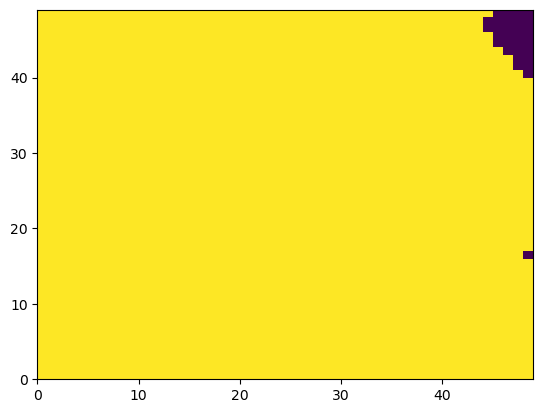

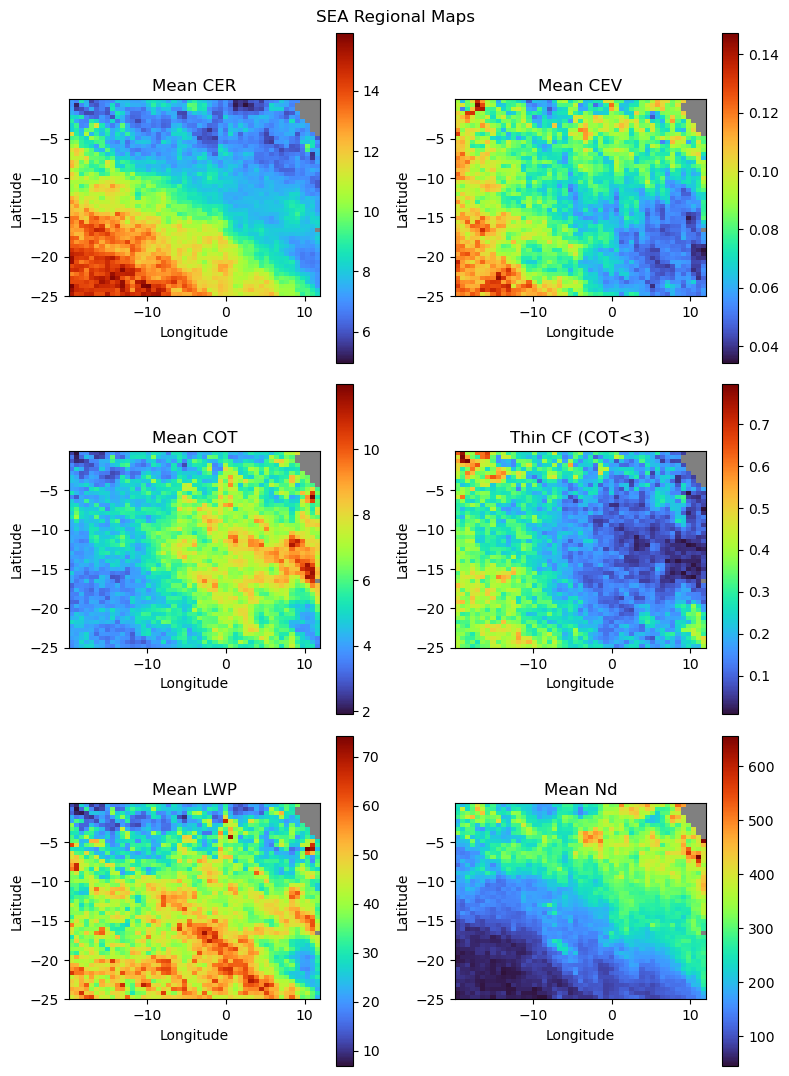

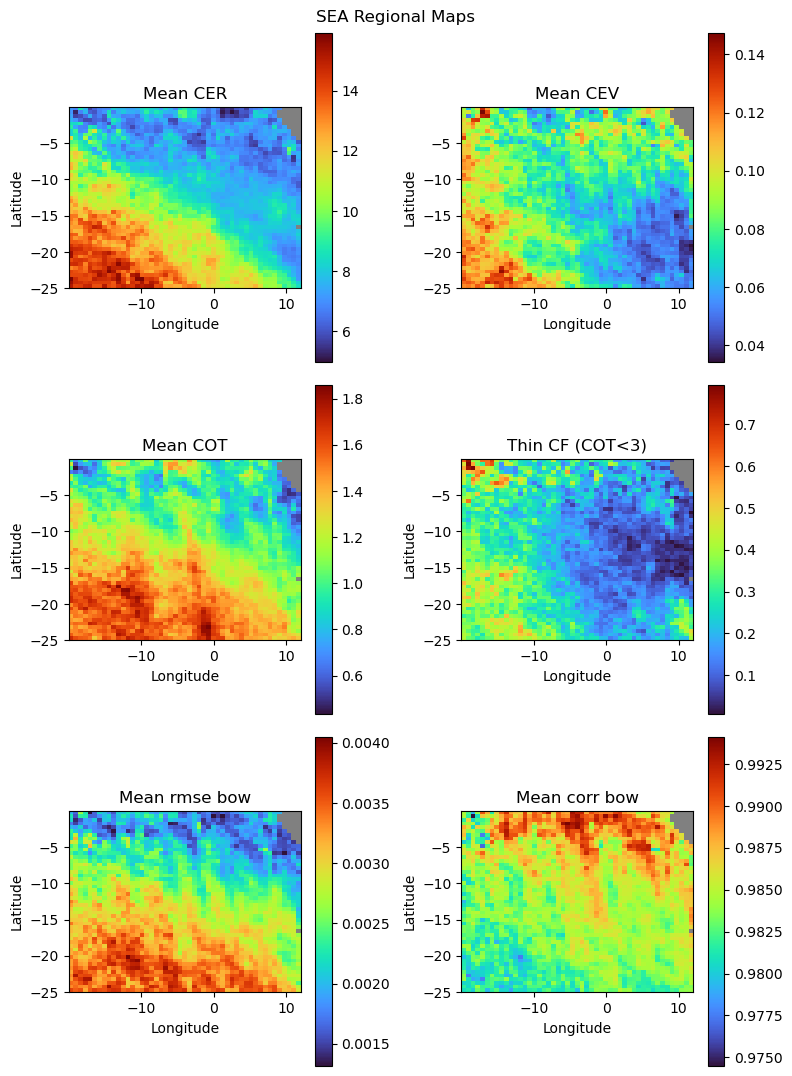

In [73]:
xbins = np.linspace(np.nanmin(lon),np.nanmax(lon),50) 
ybins = np.linspace(np.nanmin(lat),np.nanmax(lat),50) 

counts, xedge, yedge = np.histogram2d(lon, lat, bins=(xbins, ybins))
counts, xedge, yedge = np.histogram2d(lon, lat, bins=(xbins, ybins))
sum_re,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=er)
sum_ve,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=ev)
sum_re_RFT,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=er_RFT)
sum_ve_RFT,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=ev_RFT)
sum_tau,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=tau)
sum_tau_log,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(tau))
sum_LWP,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=lwp)
sum_Nd,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=cdnc)
sum_CTH,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=cth)
sum_lindex,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=lindex)
sum_lon,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.abs(lon))
sum_lat,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.abs(lat))
sum_thin_frac,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=(tau<=3))
sum_CC_AU,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(-CC[0].magnitude))
sum_CC_SC,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=np.log10(-CC[1].magnitude))
sum_rmse_bow,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=rmse_bow)
sum_corr_bow,   _, _ = np.histogram2d(lon, lat, bins=(xbins, ybins), weights=corr_bow)


# Mean and (optional) standard deviation of z per bin
with np.errstate(divide='ignore', invalid='ignore'):
    mean_re = sum_re / counts
    mean_ve = sum_ve / counts
    mean_re_RFT = sum_re_RFT / counts
    mean_ve_RFT = sum_ve_RFT / counts
    mean_tau = sum_tau / counts
    mean_tau_log = 10**(sum_tau_log / counts)
    mean_LWP = sum_LWP / counts
    mean_Nd = sum_Nd / counts
    mean_CTH = sum_CTH / counts
    mean_lindex = sum_lindex / counts
    mean_thin_frac = sum_thin_frac / counts
    mean_lon = sum_lon / counts
    mean_lat = sum_lat / counts
    mean_CC_AU = 10**(sum_CC_AU / counts)
    mean_CC_SC = 10**(sum_CC_SC / counts)
    mean_rmse_bow = sum_rmse_bow / counts    
    mean_corr_bow = sum_corr_bow / counts


xbc=(xbins[0:-1]+xbins[1:])/2 #bin centers not edges
ybc=(ybins[0:-1]+ybins[1:])/2
[lon_g,lat_g]=np.meshgrid(xbc,ybc)

LM = ~vec_is_over_land(lat_g,lon_g)  # True = land, False = ocean
plt.pcolormesh(LM)
plt.show()

fig,ax = plt.subplots(3,2,figsize=(8, 11))
cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
plt.suptitle('SEA Regional Maps')

titles={}
ims={}

titles[(0,0)] = 'Mean CER'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,np.where(LM, mean_re.T, np.nan),cmap=cmap)#norm=LogNorm(vmin=np.nanmin(np.stack([mean_CC_AU,mean_CC_SC])), vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(0,1)] = 'Mean CEV'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,np.where(LM, mean_ve.T, np.nan),cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean COT'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,np.where(LM, mean_tau_log.T, np.nan),cmap=cmap)
titles[(1,1)] = 'Thin CF (COT<3)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,np.where(LM, mean_thin_frac.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(2,0)] = 'Mean LWP'
ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,np.where(LM, mean_LWP.T, np.nan),cmap=cmap)
titles[(2,1)] = 'Mean Nd'
ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,np.where(LM, mean_Nd.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))


for i in range(3):
    for j in range(2):
        #ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        #ax[i,j].set_yscale('log')
        #ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("Longitude")
        ax[i,j].set_ylabel("Latitude")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])

plt.tight_layout()
plt.show()

fig,ax = plt.subplots(3,2,figsize=(8, 11))
cmap=plt.colormaps['turbo']
cmap.set_bad('gray', alpha=1.0)
plt.suptitle('SEA Regional Maps')

titles={}
ims={}

titles[(0,0)] = 'Mean CER'
ims[(0,0)] = ax[0,0].pcolormesh(xedge,yedge,np.where(LM, mean_re.T, np.nan),cmap=cmap)#norm=LogNorm(vmin=np.nanmin(np.stack([mean_CC_AU,mean_CC_SC])), vmax=np.nanmax(np.stack([mean_CC_AU,mean_CC_SC]))))
titles[(0,1)] = 'Mean CEV'
ims[(0,1)] = ax[0,1].pcolormesh(xedge,yedge,np.where(LM, mean_ve.T, np.nan),cmap=cmap)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(1,0)] = 'Mean COT'
ims[(1,0)] = ax[1,0].pcolormesh(xedge,yedge,np.where(LM, mean_lindex.T, np.nan),cmap=cmap)
titles[(1,1)] = 'Thin CF (COT<3)'
ims[(1,1)] = ax[1,1].pcolormesh(xedge,yedge,np.where(LM, mean_thin_frac.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))
titles[(2,0)] = 'Mean rmse bow'
ims[(2,0)] = ax[2,0].pcolormesh(xedge,yedge,np.where(LM, mean_rmse_bow.T, np.nan),cmap=cmap)
titles[(2,1)] = 'Mean corr bow'
ims[(2,1)] = ax[2,1].pcolormesh(xedge,yedge,np.where(LM, mean_corr_bow.T, np.nan),cmap=cmap)#,vmax=0.25)#,norm=LogNorm(vmin=np.nanmin(h_norm), vmax=0.12))


for i in range(3):
    for j in range(2):
        #ax[i,j].plot([15,100], [10,300], color='black', linestyle='--', linewidth=2, label='$r_e=15\,\mathrm{\mum}$')
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts.T, levels=[hist_levels], colors="white", linestyles="--", linewidths=1)# 95% interval
        #ax[i,j].contour(xedge[:-1], yedge[:-1], counts, levels=hist_levels[1], colors="white", linestyles="--", linewidths=2)

        #ax[i,j].set_yscale('log')
        #ax[i,j].set_xscale('log')
        ax[i,j].set_xlabel("Longitude")
        ax[i,j].set_ylabel("Latitude")
        ax[i,j].set_title(titles[i,j])
        ax[i,j].set_aspect('equal', adjustable='box')
        fig.colorbar(ims[(i,j)],ax=ax[i,j])

plt.tight_layout()
plt.show()


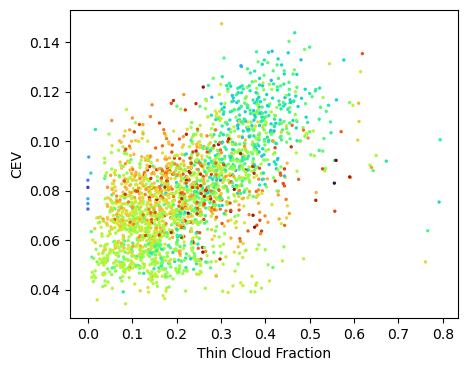

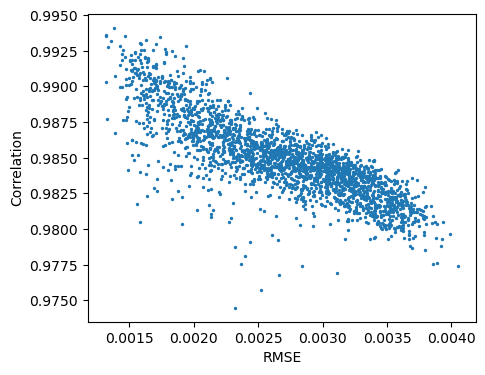

0.577162368691877


In [72]:
fig,ax = plt.subplots(1,1,figsize=(5,4))
mask=LM
cmap=plt.colormaps['turbo']
ax.scatter(mean_thin_frac[mask], mean_ve[mask],c=mean_corr_bow[mask], s=2, cmap=cmap)
ax.set_xlabel("Thin Cloud Fraction")
ax.set_ylabel("CEV")
plt.show()

fig,ax = plt.subplots(1,1,figsize=(5,4))
mask=LM
ax.scatter(mean_rmse_bow[mask], mean_corr_bow[mask], s=2)
ax.set_xlabel("RMSE")
ax.set_ylabel("Correlation")
plt.show()

corr=np.corrcoef(mean_thin_frac[mask].ravel(),mean_ve[mask].ravel())
correlation=corr[1,0]
print(correlation)